# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [53]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Data Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Statistical Analysis
# =====================================================
import scipy.stats as stats
from math import ceil


# 4. Data Preprocessing
# =====================================================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


# 5. Model Evaluation
# =====================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 6. Path Configuration
# =====================================================
import os


# 7. Utilities
# =====================================================
import textwrap
import warnings

warnings.filterwarnings('ignore')



# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   

In [54]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")
FINAL_DATA = os.path.join(DATA, "05_Final_Data")

EDA = os.path.join(PROJECT_ROOT, "03_EDA")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "04_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "05_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "06_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")

FINAL_SCORES = os.path.join(PROJECT_ROOT, "07_Final_ESG_Scores")
FINAL_SCORES_EXCEL = os.path.join(FINAL_SCORES, "01_Excel")
FINAL_SCORES_FIG = os.path.join(FINAL_SCORES, "02_Figures")

# <span style="color:#e0bda8">3. Reading the Data</span>

### Variable Selection

Although the World Bank database provides a total of **195 indicators**, only **78 indicators** were selected for this study, in alignment with the analytical framework proposed by the World Bank itself.

The selection was guided by several methodological considerations. First, the chosen indicators are already **organized into well-defined subcategories** within the World Bank framework, ensuring conceptual coherence and interpretability across dimensions. This structured organization facilitates meaningful comparisons between countries and reduces redundancy among variables.

Second, limiting the number of indicators helps mitigate the **curse of dimensionality**, which can negatively affect model performance, increase computational complexity, and reduce statistical robustness when working with high-dimensional datasets. By focusing on a reduced yet representative subset of variables, the analysis achieves a better balance between informational richness and methodological efficiency.

Third, the selected indicators exhibit **broader data availability and consistency across countries and time**, which is crucial for cross-country and longitudinal analyses. Indicators with excessive missing values or limited temporal coverage were deliberately excluded to enhance the reliability of the results.

Finally, prioritizing indicators endorsed within an established institutional framework ensures that the variables are **policy-relevant, widely validated, and commonly used in empirical research**, thereby strengthening the credibility and comparability of the findings.





In [55]:
excel_file = os.path.join(DATA_RAW, "esgdata_download-2026-01-09.xlsx")

csv_esg = os.path.join(DATA_RAW, "esgdata.csv")
csv_framework = os.path.join(DATA_RAW, "framework.csv")

# Create csv files from excel sheets (if they don't exist yet) to speed up loading in future runs
if not os.path.exists(csv_esg) or not os.path.exists(csv_framework):

    print("Creating CSV files from Excel...")

    df_raw = pd.read_excel(excel_file, sheet_name="Data")
    framework = pd.read_excel(excel_file, sheet_name="Framework")

    df_raw.to_csv(csv_esg)
    framework.to_csv(csv_framework)

df_raw = pd.read_csv(csv_esg)
framework = pd.read_csv(csv_framework)

Creating CSV files from Excel...


In [56]:
env_framework = framework[framework['ESG Pillar'] == 'Environment'] 
env_indicators = list(env_framework['Indicator name'].unique())

soc_framework = framework[framework['ESG Pillar'] == 'Social']
soc_indicators = list(soc_framework['Indicator name'].unique())

gov_framework = framework[framework['ESG Pillar'] == 'Governance']
gov_indicators = list(gov_framework['Indicator name'].unique())

esg_indicators = env_indicators + soc_indicators + gov_indicators

In [57]:
df_framework = df_raw[df_raw['Indicator name'].isin(esg_indicators)]

In [58]:
df_framework.shape

(15075, 71)

In [59]:
df_framework.head()

,Unnamed: 0,ISO3 code,Economy,Indicator code,Indicator name,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,0,ABW,Aruba,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,NaN,NaN
1,1,AFG,Afghanistan,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,57.8784,57.9550,58.0317,58.1160,58.1237,58.1927,58.2295,58.2310,58.2555,58.2709,58.3169,58.3352,58.3371,58.3388,58.3388,58.3383,58.3383,58.3383,58.3368,58.3368,58.3429,58.3444,58.3444,58.3444,58.3444,58.3444,58.3307,58.3230,58.3230,58.3230,58.3077,58.3077,58.1605,57.9749,57.8983,57.8891,57.9473,58.0593,57.8998,57.9458,57.9473,57.9397,58.0838,58.1513,58.1344,58.1237,58.1298,58.1329,58.1329,58.1344,58.1313,58.1298,58.1237,58.1237,58.1237,58.1237,58.1237,58.2770,58.2770,58.7415,58.7415,58.7415,58.4395,NaN,NaN
2,2,AGO,Angola,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,36.2373,36.2437,36.2413,36.2477,36.2453,36.2517,36.2573,36.2637,36.2774,36.2597,36.2413,36.2236,36.2052,36.1875,36.1699,35.9910,35.9734,35.9549,35.9293,35.9068,35.8771,35.8587,35.8370,35.8146,35.7969,35.7303,35.7127,35.6950,35.6766,35.6589,35.6806,35.7031,35.7023,35.7023,35.6862,35.6517,35.6541,35.7047,35.7480,35.7127,35.6261,35.6445,35.6934,35.5418,35.4400,35.4031,35.4897,35.4496,35.7985,35.9750,36.3488,36.3383,36.4867,36.6359,36.7282,36.7562,36.7089,36.7193,36.7819,36.7883,36.8308,36.9471,36.9479,NaN,NaN
3,3,ALB,Albania,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,44.9635,44.9635,45.0000,44.8905,45.1460,45.2555,45.4015,45.2555,45.0730,44.8905,43.7956,42.8467,41.8248,40.9489,39.4161,39.2336,40.4745,40.6569,40.7664,40.8029,40.7299,40.6569,40.5109,40.6204,40.5839,40.5474,40.5474,40.7664,40.5109,40.9124,41.1314,41.1314,41.0949,41.0949,41.1314,41.2774,41.4234,41.5693,41.7883,41.7518,41.5693,41.6058,40.9124,40.9489,39.3066,40.8759,40.8394,43.1022,43.8431,43.8431,43.8321,43.8431,43.3321,42.8573,42.8577,43.1277,42.8570,42.8497,42.8467,42.5385,41.4719,41.4453,38.1241,NaN,NaN
4,4,AND,Andorra,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,55.3191,55.3191,55.3191,55.3191,55.3191,55.3191,55.3191,55.3191,55.3191,55.3191,53.1915,53.1915,51.0638,51.0638,51.0638,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.9362,48.4043,48.6170,48.6383,48.5319,46.3830,46.3404,44.1915,44.1702,44.1915,42.0638,42.0638,39.9149,40.0213,40.0000,40.0213,40.0426,40.0426,40.0723,40.0002,39.9517,39.9068,39.9068,39.8740,NaN,NaN


In [60]:
framework.head()

,Unnamed: 0,ESG Pillar,Group,Indicator code,Indicator name
0,0,Environment,Emissions & pollution,EN.ATM.PM25.MC.M3,"PM2.5 air pollution, mean annual exposure (mic..."
1,1,Environment,Emissions & pollution,EN.GHG.CO2.MT.CE.AR5,Carbon dioxide (CO2) emissions (total) excludi...
2,2,Environment,Emissions & pollution,EN.GHG.CO2.PC.CE.AR5,Carbon dioxide (CO2) emissions excluding LULUC...
3,3,Environment,Emissions & pollution,EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - ...
4,4,Environment,Emissions & pollution,EN.GHG.CH4.MT.CE.AR5,Methane (CH4) emissions (total) excluding LULU...


# <span style="color:#e0bda8">4. Missing Values by Year </span>

In [61]:
pd.set_option('display.max_rows', None)
df_raw.isna().sum().sort_values(ascending=False)

2025              34048
1960              31710
1961              30680
1962              30660
1963              30651
1964              30641
1965              30605
1966              30587
1967              30565
1968              30547
1969              30540
1970              24170
1972              24041
1973              24040
1974              24039
1971              24039
1976              23940
1978              23914
1977              23914
1975              23912
1979              23890
1982              23613
1983              23602
1980              23587
1984              23540
1981              23537
1985              23445
1986              23444
1988              23353
1987              23322
1989              23285
2024              22741
1990              20530
1991              19331
1992              19081
1993              18984
1994              18965
2023              16226
2022              14480
2021              13257
1995               8732
1997            

### Time Period Selection (2012–2020)

The years from **2012 to 2020** were selected based on the following criteria:

1. **Recency**  
   Using recent data is essential to accurately reflect current trends and patterns.

2. **Dimensionality**  
   This time window provides a sufficient number of observations to support the development and evaluation of the proposed methods.

3. **Data Completeness**  
   After 2020, there is a substantial increase in missing values across multiple variables, which could negatively affect the robustness and reliability of the analysis.

In [62]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34208 entries, 0 to 34207
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      34208 non-null  int64  
 1   ISO3 code       34208 non-null  object 
 2   Economy         34208 non-null  object 
 3   Indicator code  34208 non-null  object 
 4   Indicator name  34208 non-null  object 
 5   1960            2498 non-null   float64
 6   1961            3528 non-null   float64
 7   1962            3548 non-null   float64
 8   1963            3557 non-null   float64
 9   1964            3567 non-null   float64
 10  1965            3603 non-null   float64
 11  1966            3621 non-null   float64
 12  1967            3643 non-null   float64
 13  1968            3661 non-null   float64
 14  1969            3668 non-null   float64
 15  1970            10038 non-null  float64
 16  1971            10169 non-null  float64
 17  1972            10167 non-null 

# <span style="color:#e0bda8">5. Transformation to Panel Data Structure</span>

In [63]:
cols_metadata = list(df_raw.loc[:, 'ISO3 code':'Indicator name'].columns)
cols_years = list(df_raw.loc[:, '2012':'2020'].columns)

df_selected = df_framework[cols_metadata + cols_years]

In [64]:
df_panel = df_selected.melt(id_vars=['ISO3 code', 'Economy', 'Indicator code', 'Indicator name'],
                  value_vars=[str(y) for y in range(2012, 2021)],
                  var_name='Year',
                  value_name='Value')

df_panel['Year'] = df_panel['Year'].astype('int64')

In [65]:
df_panel.head()

,ISO3 code,Economy,Indicator code,Indicator name,Year,Value
0,ABW,Aruba,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,11.1111
1,AFG,Afghanistan,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,58.1298
2,AGO,Angola,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,36.3383
3,ALB,Albania,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,43.8431
4,AND,Andorra,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,39.9149


In [66]:
df_panel_wide = df_panel.pivot_table(
    index=['ISO3 code', 'Economy', 'Year'],   
    columns='Indicator name',               
    values='Value'
).reset_index()

df_panel_wide = df_panel_wide.set_index(['Economy', 'Year'])

In [67]:
df_panel_wide.head()

Indicator name ISO3 code  \
Economy Year               
Aruba   2012         ABW   
        2013         ABW   
        2014         ABW   
        2015         ABW   
        2016         ABW   

Indicator name  Access to clean fuels and technologies for cooking  (% of population)  \
Economy Year                                                                            
Aruba   2012                                                  NaN                       
        2013                                                  NaN                       
        2014                                                  NaN                       
        2015                                                  NaN                       
        2016                                                  NaN                       

Indicator name  Access to electricity (% of population)  \
Economy Year                                              
Aruba   2012                                      100.0   
        2013                                      100.0   
        2014                                      100.0   
        2015                                      100.0   
        2016                                      100.0   

Indicator name  Adjusted savings, natural resources depletion (% of GNI)  \
Economy Year                                                               
Aruba   2012                                               0.0033          
        2013                                               0.0026          
        2014                                               0.0034          
        2015                                               0.0025          
        2016                                               0.0035          

Indicator name  Adjusted savings, net forest depletion (% of GNI)  \
Economy Year                                                        
Aruba   2012                                               0.0020   
        2013                                               0.0026   
        2014                                               0.0034   
        2015                                               0.0025   
        2016                                               0.0035   

Indicator name  Agricultural land (% of land area)  \
Economy Year                                         
Aruba   2012                               11.1111   
        2013                               11.1111   
        2014                               11.1111   
        2015                               11.1111   
        2016                               11.1111   

Indicator name  Agriculture, forestry, and fishing, value added (% of GDP)  \
Economy Year                                                                 
Aruba   2012                                               0.0215            
        2013                                               0.0178            
        2014                                               0.0148            
        2015                                               0.0125            
        2016                                               0.0186            

Indicator name  Annual freshwater withdrawals, total (% of internal resources)  \
Economy Year                                                                     
Aruba   2012                                                  NaN                
        2013                                                  NaN                
        2014                                                  NaN                
        2015                                                  NaN                
        2016                                                  NaN                

Indicator name  Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                        
Aruba   2012                                               0.3754            

The selected dataset is initially in a wide format, with **each year as a separate column** and all indicators stacked in the `Indicator name` column. To prepare the data for analysis, we perform two main steps:

1. **Melt the dataset**  
   Using `melt`, the year columns are converted into a single column called `Year`, while their corresponding values go into a column called `Value`.  
   This allows each row to represent a single observation of a country, indicator, and year.

2. **Pivot the dataset**  
   Using `pivot_table`, each unique indicator in the `Indicator name` column is transformed into its **own separate column**, with the corresponding values filled in.  
   After this step, the dataset has one row per country and year, with all indicators as separate columns, a **classic panel (longitudinal) format** suitable for analysis.

Finally, we set a **MultiIndex with `Economy` and `Year`**, which makes it easier to access, aggregate, and manipulate the data by country and over time.

# <span style="color:#e0bda8">6. Missing Values by Economy </span>

In [68]:
missing_by_economy = (
    df_panel_wide
    .isna()
    .groupby(level='Economy')
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(missing_by_economy)

Economy
Channel Islands                   571
St. Martin (French part)          532
Isle of Man                       524
Sint Maarten (Dutch part)         519
Northern Mariana Islands          486
Curacao                           476
Kosovo                            472
Gibraltar                         470
Faroe Islands                     453
British Virgin Islands            435
Monaco                            424
Liechtenstein                     419
San Marino                        412
American Samoa                    401
Bermuda                           394
Turks and Caicos Islands          390
New Caledonia                     381
Greenland                         374
Cayman Islands                    372
French Polynesia                  372
Guam                              367
Aruba                             361
Virgin Islands (U.S.)             354
Andorra                           347
Marshall Islands                  316
Nauru                             316
Pala

### Economy Selection (European Countries)

European countries (from Council of Europe) were selected for this study because they generally exhibit **lower levels of missing data** compared to other regions, which ensures more reliable and consistent analysis. In addition, European economies share **similar cultural, institutional, and socio-economic characteristics**, which may enhance comparability and interpretability of the results.

From the Council of Europe countries, small island economies (Malta, Cyprus) and territories with excessive missing values (Andorra, Kosovo, Liechtenstein, Monaco, and San Marino) were not considered, producing a final sample of 37 countries.

In [69]:
europe_countries = ["Albania", "Armenia", "Austria", "Belgium", "Bosnia and Herzegovina", "Bulgaria", 
                    "Croatia", "Czechia", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", 
                    "Hungary", "Iceland", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Moldova", 
                    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", "Romania", 
                    "Serbia", "Slovak Republic", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom"]

df_europe = df_panel_wide[df_panel_wide.index.get_level_values('Economy').isin(europe_countries)] 

df_europe = df_europe.sort_index()

# <span style="color:#e0bda8">7. Dataset Overview</span>

In [70]:
df_europe.shape # 9 years * 37 countries, 78 indicators + ISO3 code

(333, 79)

In [71]:
df_europe.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 333 entries, ('Albania', np.int64(2012)) to ('United Kingdom', np.int64(2020))
Data columns (total 79 columns):
 #   Column                                                                                                          Non-Null Count  Dtype  
---  ------                                                                                                          --------------  -----  
 0   ISO3 code                                                                                                       333 non-null    object 
 1   Access to clean fuels and technologies for cooking  (% of population)                                           324 non-null    float64
 2   Access to electricity (% of population)                                                                         333 non-null    float64
 3   Adjusted savings, natural resources depletion (% of GNI)                                                        331 non-null    

In [72]:
# Calculating the number of missing values per variable
missing_values = df_europe.isnull().sum()

# Adding percentage of missing values
total_rows = len(df_europe)
missing_percentage = (missing_values / total_rows) * 100

# Creating a DataFrame with the count and percentage of missing values
missing_data = pd.DataFrame(
    {"Missing Values": missing_values, "Percentage": missing_percentage}
)

# Sorting by the frequency of missing values
sorted_missing_data = missing_data.sort_values(by="Missing Values", ascending=False)

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', None)

sorted_missing_data.head(76)

,Missing Values,Percentage
Indicator name,,
Primary Forest Loss,333,100.000000
"Children in employment, total (% of children ages 7-14)",331,99.399399
Unmet need for contraception (% of married women ages 15-49),319,95.795796
"Literacy rate, adult total (% of people ages 15 and above)",315,94.594595
"Mammal species, threatened",296,88.888889
Proportion of bodies of water with good ambient water quality,271,81.381381
"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",259,77.777778
Coastal protection,99,29.729730
Poverty headcount ratio at national poverty lines (% of population),87,26.126126


### Handling of Missing Values in Indicators

The indicator **Primary Forest Loss** exhibits **100% missing values** across the dataset and will therefore be **immediately removed** from the analysis, as it provides no usable information.

Several other indicators also show a **very high proportion of missing values**, including:

- Children in employment, total (% of children ages 7-14) — 98.8% missing  
- Unmet need for contraception (% of married women ages 15-49) — 94.3% missing  
- Mammal species, threatened — 90.9% missing  
- Literacy rate, adult total (% of people ages 15 and above) — 87.7% missing  
- Proportion of bodies of water with good ambient water quality — 86.1% missing  
- Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total) — 72.7% missing  
- Coastal protection — 69.1% missing

While these indicators are likely to be **removed during preprocessing** due to their high level of missing data, they will be **temporarily retained** for **exploratory analysis** to assess their potential relevance and relationships with other variables.


In [73]:
env_indicators = [e for e in env_indicators if e != 'Primary Forest Loss']
esg_indicators = [e for e in esg_indicators if e != 'Primary Forest Loss']
df_europe = df_europe[esg_indicators]

In [74]:
df_europe.head()

Indicator name  PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)  \
Economy Year                                                                             
Albania 2012                                              20.9627                        
        2013                                              19.4075                        
        2014                                              19.3679                        
        2015                                              19.1216                        
        2016                                              17.6022                        

Indicator name  Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                        
Albania 2012                                               4.5385                   
        2013                                               4.7703                   
        2014                                               5.1022                   
        2015                                               4.8756                   
        2016                                               4.5382                   

Indicator name  Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
Economy Year                                                                                 
Albania 2012                                               1.5865                            
        2013                                               1.6935                            
        2014                                               1.8394                            
        2015                                               1.7851                            
        2016                                               1.6874                            

Indicator name  Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)  \
Economy Year                                                                                                 
Albania 2012                                               5.3536                                            
        2013                                               1.3449                                            
        2014                                               1.2246                                            
        2015                                               1.2718                                            
        2016                                               1.3456                                            

Indicator name  Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                 
Albania 2012                                               2.6032            
        2013                                               2.6766            
        2014                                               2.7464            
        2015                                               2.7870            
        2016                                               2.7356            

Indicator name  Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                       
Albania 2012                                               0.9459                  
        2013                                               0.8989                  
        2014                                               0.9708                  
        2015                                               0.9918                  
        2016                                               0.9786                  

Indicator name  Total greenhouse gas emissions excluding LULUCF (Mt CO2e)  \
Economy Year                                                                
Albania 2012                                         

In [75]:
env_europe = df_europe[env_indicators]     
soc_europe = df_europe[soc_indicators]
gov_europe = df_europe[gov_indicators]

In [76]:
env_europe.isna().sum().sum()/env_europe.size*100 # 7.6% of Environmental values missing

np.float64(7.639992934110581)

In [77]:
soc_europe.isna().sum().sum()/soc_europe.size*100 # 13.4% of Social values missing

np.float64(13.386463386463387)

In [78]:
gov_europe.isna().sum().sum()/gov_europe.size*100 # 6.9% of Governance values missing

np.float64(6.906906906906906)

# <span style="color:#e0bda8">8. Univariate Analysis</span>

### <span style="color:#e0bda8">8.0.Auxiliary Functions </span>

In [79]:
def boxplots(init_df, pillar_title=None, pillar_png=None):
    """
    Generates boxplots for all numeric columns in the dataset.

    Parameters:
        init_df (DataFrame): Input dataset.
        pillar_title (str, optional): Title for the pillar (e.g., "Environmental", "Social", "Governance") to be displayed in the figure title.
        pillar_png (str, optional): Filename prefix for saving the figure.
    """

    # Select numeric columns only
    numeric_cols = init_df.select_dtypes(include=[np.number]).columns.tolist()

    # Handle case with no numeric data
    if len(numeric_cols) == 0:
        print(f"No numeric columns found in {init_df}.")
    else:
        cols_per_row = 4
        rows = ceil(len(numeric_cols) / cols_per_row)

        # Create subplot grid
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
        axes = axes.flatten()

        fig.suptitle(f"Distributional Overview of {pillar_title} Indicators", fontsize=13, fontweight='bold', y=0.95)

        wrap_width = 30

        # Plot each numeric variable as a boxplot
        for i, col in enumerate(numeric_cols):
            ax = axes[i]
            sns.boxplot(y=init_df[col].dropna(), ax=ax, color='skyblue')

            # Wrap long column names for better readability
            wrapped = "\n".join(textwrap.wrap(col, wrap_width))
            ax.set_title(wrapped, fontsize=9, pad=6)

            # Remove x-axis elements for cleaner layout
            ax.set_xlabel('')
            ax.set_xticks([])

            # Keep y-axis ticks but remove label
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelsize=8)

            # Center title alignment
            ax.title.set_ha('center')

        # Remove unused subplot axes
        for j in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[j])

        # Adjust spacing dynamically based on number of rows
        hspace = 0.6 if rows <= 4 else 0.8
        fig.subplots_adjust(hspace=hspace, wspace=0.35)

        # Save figure if filename is provided
        if pillar_png:
            plt.savefig(
                os.path.join(EDA, f'{pillar_png}_boxplots.png'),
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

In [80]:
def skew_kurt_outliers(init_df):
    """
    Computes skewness, kurtosis, and percentage of outliers for each column.

    Outliers are defined using the IQR method (1.5 * IQR rule).

    Parameters:
        init_df (DataFrame): Input dataset.

    Returns:
        DataFrame: Summary statistics per feature, sorted by outlier percentage.
    """

    results = []

    for col in init_df.columns:
        data = init_df[col].dropna()

        # Handle empty columns
        if len(data) == 0:
            skewness = np.nan
            kurtosis = np.nan
            outlier_pct = np.nan
        else:
            # Compute distribution shape metrics
            skewness = abs(stats.skew(data))
            kurtosis = abs(stats.kurtosis(data))

            # Compute IQR-based outlier thresholds
            q25, q75 = np.percentile(data, [25, 75])
            iqr = q75 - q25
            upper = q75 + 1.5 * iqr
            lower = q25 - 1.5 * iqr

            # Calculate percentage of outliers
            outlier_pct = ((data > upper) | (data < lower)).sum() / len(data) * 100

        results.append({
            "Indicator": col,
            "Skewness": skewness,
            "Kurtosis": kurtosis,
            "Outlier %": outlier_pct,
        })

    # Create summary DataFrame and sort by outlier prevalence
    df_skewness_outliers = pd.DataFrame(results)
    df_skewness_outliers = df_skewness_outliers.sort_values(
        by='Outlier %',
        ascending=False
    ).reset_index(drop=True)

    return df_skewness_outliers

## <span style="color:#e0bda8">8.1. Environmental Pillar </span>

### Descriptive Statistics

In [81]:
env_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",333.0,15.31,7.39,4.90,10.09,14.23,18.68,43.29
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),315.0,108.94,158.24,3.07,15.40,44.61,105.80,817.82
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),315.0,6.73,3.21,1.59,4.57,6.20,8.32,20.47
Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e),333.0,-9.14,18.11,-60.60,-8.48,-4.20,-0.46,75.87
Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),315.0,18.21,22.30,0.54,3.58,8.71,19.71,82.60
Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e),315.0,8.38,10.00,0.24,1.77,4.00,9.01,38.45
Total greenhouse gas emissions excluding LULUCF (Mt CO2e),315.0,138.86,191.58,4.23,24.56,61.75,130.57,938.54
Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita),315.0,8.85,3.66,2.83,6.37,8.25,10.89,22.27
Electricity production from coal sources (% of total),333.0,23.35,24.41,0.00,0.70,16.25,38.80,88.69


### Boxplots

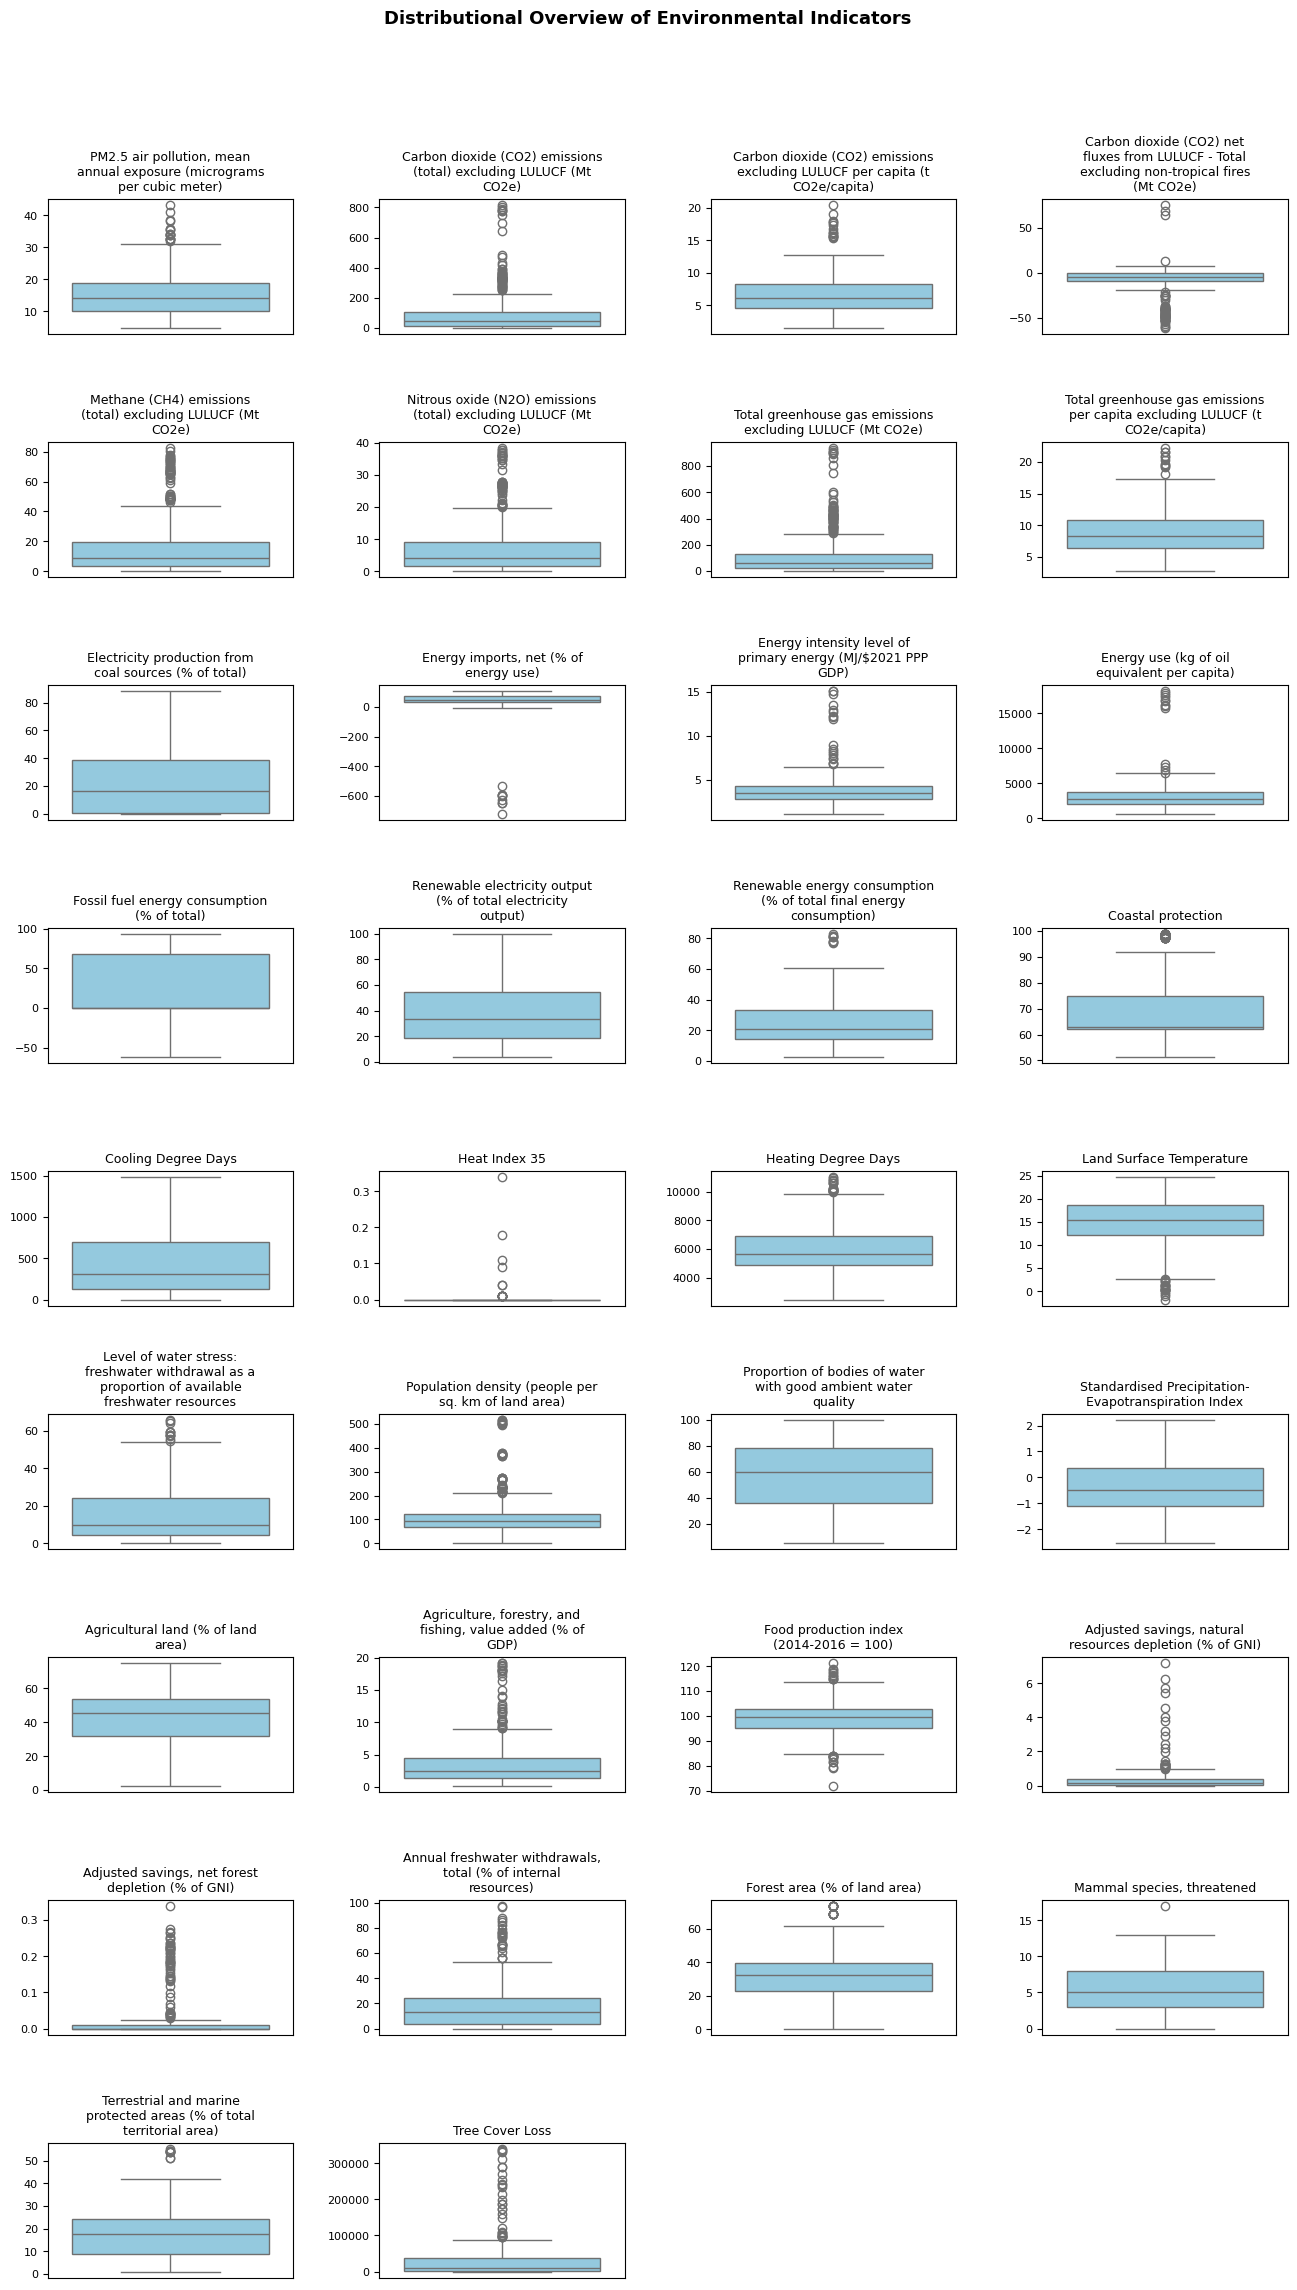

In [82]:
boxplots(env_europe, pillar_title='Environmental', pillar_png='env')

### Skewness and Percentage of Outliers

In [83]:
so_env = skew_kurt_outliers(env_europe)
so_env

,Indicator,Skewness,Kurtosis,Outlier %
0,Total greenhouse gas emissions excluding LULUC...,2.148876,4.589905,19.682540
1,Carbon dioxide (CO2) net fluxes from LULUCF - ...,0.584719,3.590622,18.318318
2,Carbon dioxide (CO2) emissions (total) excludi...,2.421979,6.366716,17.777778
3,"Adjusted savings, net forest depletion (% of GNI)",2.405274,4.510442,17.220544
4,Methane (CH4) emissions (total) excluding LULU...,1.532022,0.921176,17.142857
5,Nitrous oxide (N2O) emissions (total) excludin...,1.604147,1.429155,16.507937
6,Coastal protection,1.127445,0.201869,15.384615
7,Population density (people per sq. km of land ...,2.049130,4.784655,14.414414
8,"Agriculture, forestry, and fishing, value adde...",2.173846,4.465956,11.411411
9,Tree Cover Loss,3.091650,10.054071,9.567901


## <span style="color:#e0bda8">8.2. Social Pillar </span>

### Descriptive Statistics

In [84]:
soc_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
Access to clean fuels and technologies for cooking (% of population),324.0,94.99,12.75,40.20,100.00,100.00,100.00,100.00
Access to electricity (% of population),333.0,99.87,0.57,94.70,100.00,100.00,100.00,100.00
People using safely managed drinking water services (% of population),333.0,92.89,8.36,66.38,88.34,96.70,99.28,100.00
People using safely managed sanitation services (% of population),313.0,78.20,23.87,10.75,75.39,88.59,93.85,99.98
"Fertility rate, total (births per woman)",333.0,1.57,0.18,1.18,1.44,1.56,1.71,2.04
"Life expectancy at birth, total (years)",333.0,78.89,3.43,69.91,75.95,80.33,81.70,83.90
Population ages 65 and above (% of total population),333.0,17.62,2.89,10.49,15.71,18.25,19.67,23.38
"Government expenditure on education, total (% of government expenditure)",282.0,11.91,2.66,7.10,9.96,11.54,13.38,20.74
"Literacy rate, adult total (% of people ages 15 and above)",18.0,98.63,0.83,96.99,98.10,98.56,99.36,99.79


### Boxplots

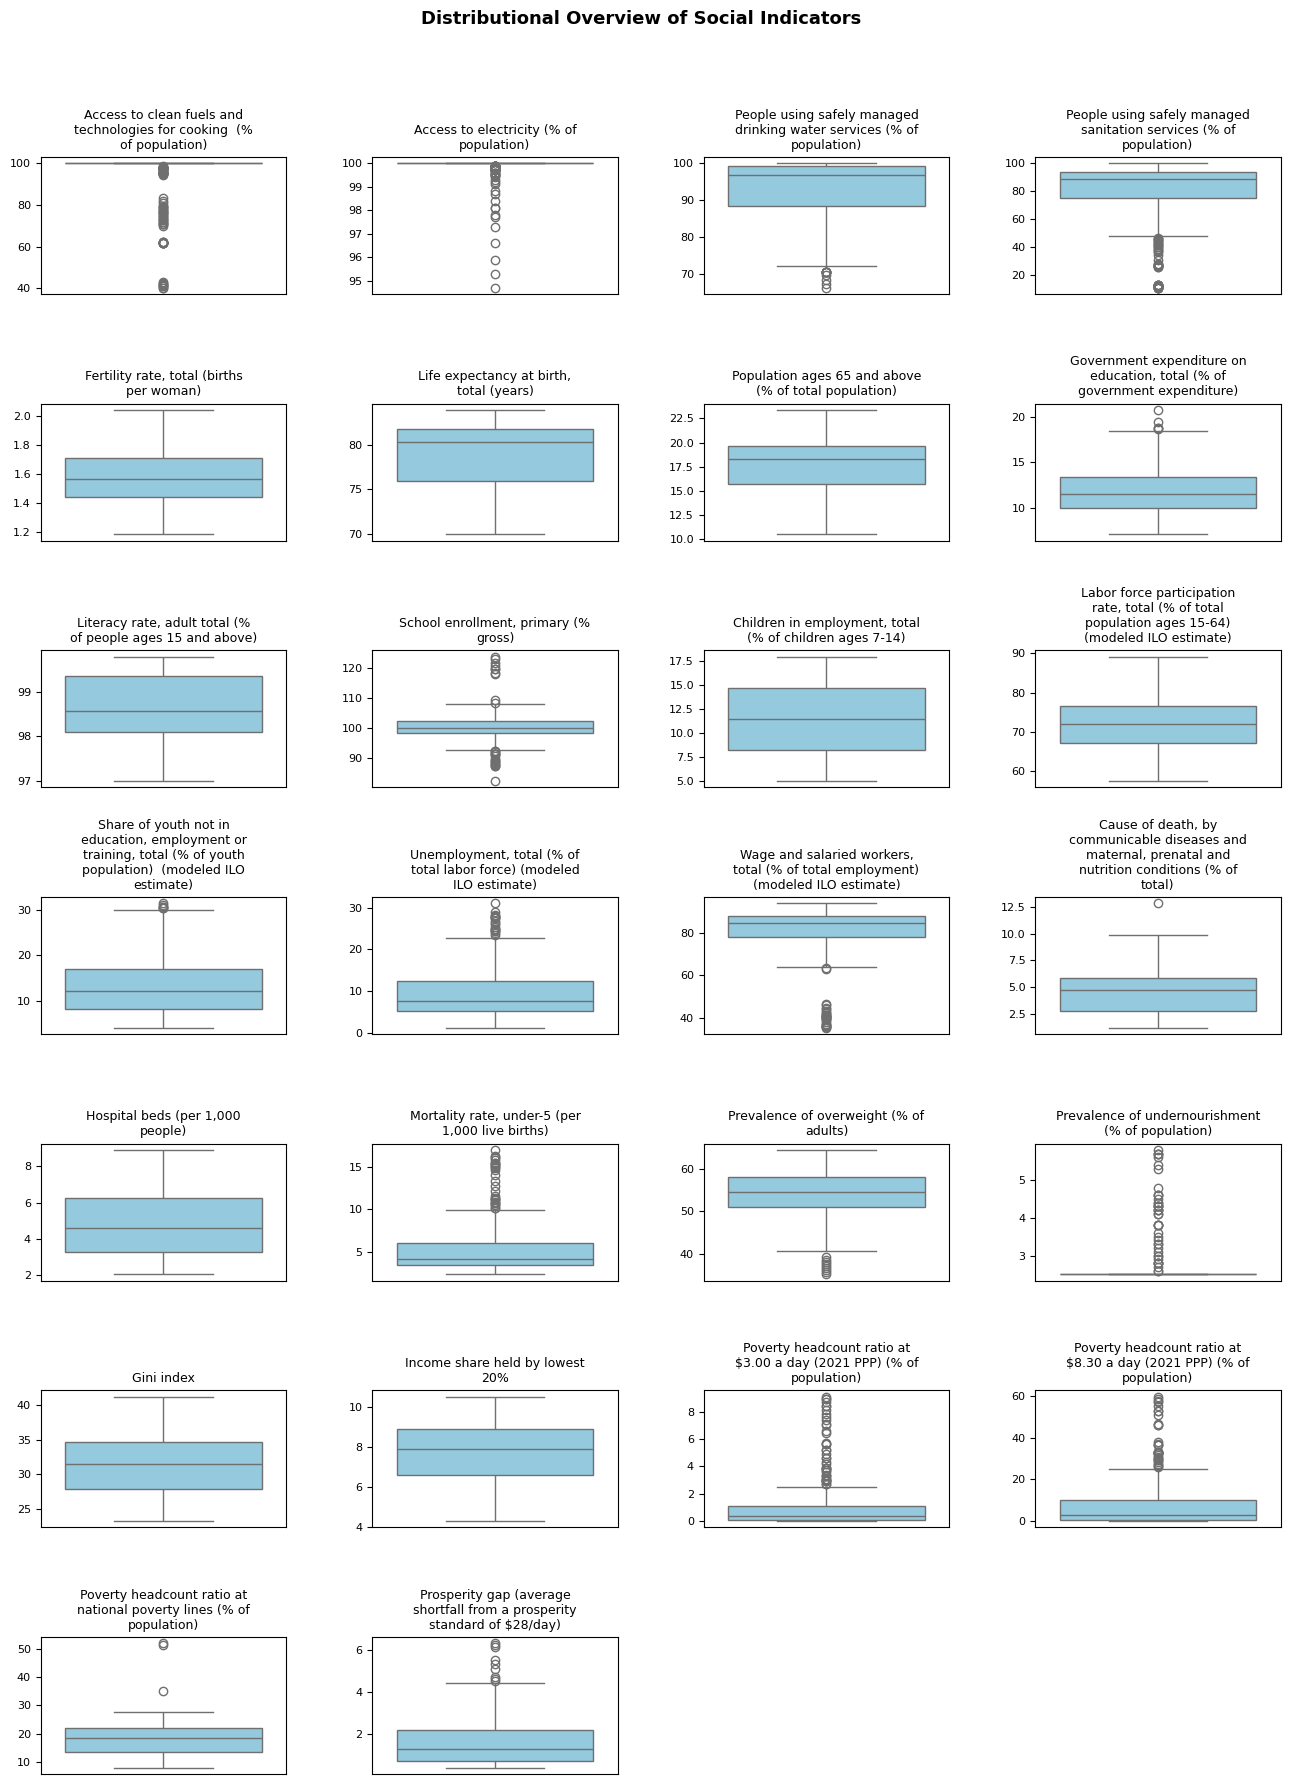

In [85]:
boxplots(soc_europe, pillar_title='Social', pillar_png='soc')

### Skewness and Percentage of Outliers

In [86]:
so_soc = skew_kurt_outliers(soc_europe)
so_soc

,Indicator,Skewness,Kurtosis,Outlier %
0,Access to clean fuels and technologies for coo...,2.823338,7.478775,22.222222
1,Access to electricity (% of population),6.250508,43.336216,15.615616
2,People using safely managed sanitation service...,1.625406,1.617883,14.376997
3,Prevalence of undernourishment (% of population),3.386609,11.090960,13.213213
4,Poverty headcount ratio at $3.00 a day (2021 P...,2.577156,6.496024,12.893082
5,Poverty headcount ratio at $8.30 a day (2021 P...,2.135310,4.376746,10.377358
6,"Mortality rate, under-5 (per 1,000 live births)",1.878327,3.196934,8.708709
7,"Wage and salaried workers, total (% of total e...",2.141420,3.914677,8.708709
8,"School enrollment, primary (% gross)",1.090235,6.166224,8.333333
9,"Unemployment, total (% of total labor force) (...",1.250191,1.010478,5.705706


## <span style="color:#e0bda8">8.3. Governance Pillar </span>

### Descriptive Statistics

In [87]:
gov_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
GDP (annual % growth),333.0,1.51,3.56,-14.99,0.45,2.07,3.28,24.62
Individuals using the Internet (% of population),333.0,77.23,14.18,34.65,68.35,78.89,88.65,99.53
Proportion of seats held by women in national parliaments (%),333.0,28.25,9.45,8.81,21.28,28.04,36.67,47.62
Ratio of female to male labor force participation rate (%) (modeled ILO estimate),333.0,80.30,7.28,61.79,75.89,81.24,84.16,101.67
"School enrollment, primary and secondary (gross), gender parity index (GPI)",301.0,1.00,0.03,0.96,0.98,1.00,1.01,1.10
Unmet need for contraception (% of married women ages 15-49),14.0,12.79,5.36,4.90,9.07,11.39,15.14,21.82
Government Effectiveness: Estimate,333.0,0.85,0.78,-1.08,0.13,0.98,1.52,2.21
Regulatory Quality: Estimate,333.0,0.96,0.65,-0.62,0.44,1.00,1.58,2.04
Economic and Social Rights Performance Score,333.0,4.55,0.52,2.91,4.53,4.75,4.87,4.99


### Boxplots

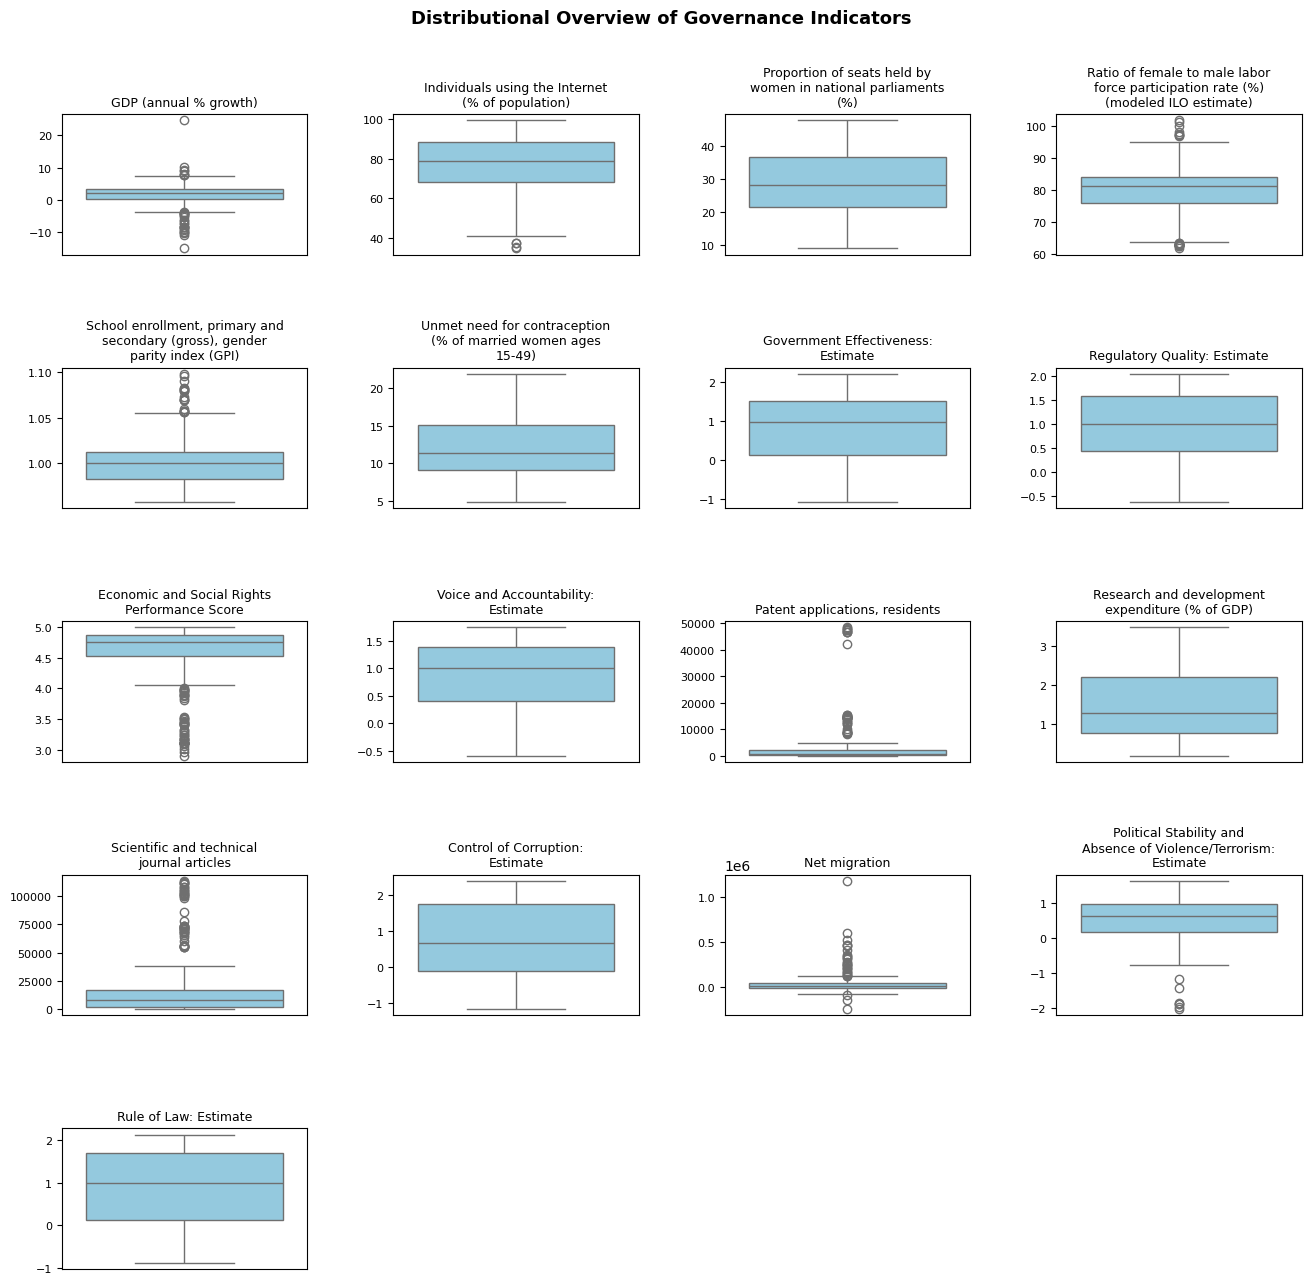

In [88]:
boxplots(gov_europe, pillar_title= 'Governance',pillar_png='gov')

### Percentage of Outliers

In [89]:
so_gov = skew_kurt_outliers(gov_europe)
so_gov

,Indicator,Skewness,Kurtosis,Outlier %
0,Economic and Social Rights Performance Score,1.756288,2.006667,15.015015
1,Scientific and technical journal articles,2.088853,3.442484,13.513514
2,"Patent applications, residents",4.370790,19.700741,11.290323
3,Net migration,4.866203,37.107656,9.309309
4,GDP (annual % growth),0.383738,7.636991,9.009009
5,"School enrollment, primary and secondary (gros...",1.162248,1.565220,6.644518
6,Ratio of female to male labor force participat...,0.261017,0.492403,6.306306
7,Political Stability and Absence of Violence/Te...,1.238628,2.662635,2.102102
8,Individuals using the Internet (% of population),0.583368,0.192106,1.201201
9,Regulatory Quality: Estimate,0.254060,0.991981,0.000000


# <span style="color:#e0bda8">9. Bivariate Analysis</span>

In [90]:
def correlation_heatmap(criteria):
    """
    Generates Spearman correlation heatmaps for each group of features.

    Parameter:
        criteria (dict): Dictionary where keys are group names and values are DataFrames.
    """

    for group_name, c in criteria.items():

        # Compute Spearman correlation matrix
        cor_spearman = c.corr(method="spearman")

        # Create upper triangle mask to avoid redundant values
        mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

        labels = cor_spearman.columns.tolist()

        # Wrap labels to improve readability in the plot
        wrapped_labels = ["\n".join(textwrap.wrap(l, width=20)) for l in labels]
        wrapped_labels_2 = [textwrap.fill(l, width=10) for l in labels]

        # Initialize figure with custom background
        fig, ax = plt.subplots(figsize=(12, 10))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        # Plot heatmap with annotations
        sns.heatmap(
            cor_spearman,
            mask=mask,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            square=True,
            cbar_kws={"shrink": 0.8},
            ax=ax,
            annot_kws={
                "color": "#000000",
                "fontweight": "bold",
                "fontsize": 12
            }
        )

        # Apply formatted axis labels
        ax.set_yticklabels(wrapped_labels, rotation=0, ha='right', color='#1e1e1e')
        ax.set_xticklabels(wrapped_labels_2, rotation=0, ha='center', color='#1e1e1e')

        ax.set_xlabel("Indicator Name", color='#1e1e1e', fontsize=14)
        ax.set_ylabel("Indicator Name", color='#1e1e1e', fontsize=14)

        # Adjust tick and title styling
        ax.tick_params(colors='#1e1e1e')
        ax.set_title(f"Spearman Rank Correlation Matrix: {group_name} Indicators", fontsize=16, color='#1e1e1e')

        # Style colorbar
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_tick_params(color='#1e1e1e')
        plt.setp(cbar.ax.get_yticklabels(), color='#1e1e1e')
        cbar.set_label('Correlation', color='#1e1e1e')

        # Create safe filename
        safe_name = group_name.lower().replace(' ', '_').replace('&', '').replace('/', '_').replace('__', '_')

        # Save figure
        plt.savefig(os.path.join(EDA, f'{safe_name}_correlation_heatmap.png'),
                    dpi=300, bbox_inches="tight")

        plt.show()


In [91]:
emissions_polution = ['PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)', 
                      'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
                      'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
                      'Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)',
                      'Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)',
                      'Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)',
                      'Total greenhouse gas emissions excluding LULUCF (Mt CO2e)',
                      'Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita)']

energy_security = ['Electricity production from coal sources (% of total)',
                   'Energy imports, net (% of energy use)',
                   'Energy intensity level of primary energy (MJ/$2021 PPP GDP)',
                   'Energy use (kg of oil equivalent per capita)',
                   'Fossil fuel energy consumption (% of total)',
                   'Renewable electricity output (% of total electricity output)',
                   'Renewable energy consumption (% of total final energy consumption)']

climate_resilience = ['Coastal protection',  
                      'Cooling Degree Days',
                      'Heat Index 35',
                      'Heating Degree Days',
                      'Land Surface Temperature',
                      'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources',
                      'Population density (people per sq. km of land area)',
                      'Proportion of bodies of water with good ambient water quality', 
                      'Standardised Precipitation-Evapotranspiration Index']

food_security = ['Agricultural land (% of land area)',
                 'Agriculture, forestry, and fishing, value added (% of GDP)',
                 'Food production index (2014-2016 = 100)']

endowment_management = ['Adjusted savings, natural resources depletion (% of GNI)',
                        'Adjusted savings, net forest depletion (% of GNI)',
                        'Annual freshwater withdrawals, total (% of internal resources)',
                        'Forest area (% of land area)',
                        'Mammal species, threatened',  
                        'Terrestrial and marine protected areas (% of total territorial area)',   
                        'Tree Cover Loss']

emissions_polution_europe = df_europe[emissions_polution] 
energy_security_europe = df_europe[energy_security] 
climate_resilience_europe = df_europe[climate_resilience]
food_security_europe = df_europe[food_security]
endowment_management_europe = df_europe[endowment_management]

In [92]:
access_services = ['Access to clean fuels and technologies for cooking  (% of population)',
                   'Access to electricity (% of population)',
                   'People using safely managed drinking water services (% of population)',
                   'People using safely managed sanitation services (% of population)']


demography = ['Fertility rate, total (births per woman)',
              'Life expectancy at birth, total (years)',
              'Population ages 65 and above (% of total population)']

education_skills = ['Government expenditure on education, total (% of government expenditure)',
                    'Literacy rate, adult total (% of people ages 15 and above)', # 1
                    'School enrollment, primary (% gross)']

employment = ['Children in employment, total (% of children ages 7-14)', #1
              'Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)',
              'Unemployment, total (% of total labor force) (modeled ILO estimate)',
              'Share of youth not in education, employment or training, total (% of youth population)  (modeled ILO estimate)',
              'Wage and salaried workers, total (% of total employment) (modeled ILO estimate)']

health_nutrition = ['Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)', 
                    'Hospital beds (per 1,000 people)',
                    'Mortality rate, under-5 (per 1,000 live births)',
                    'Prevalence of overweight (% of adults)',
                    'Prevalence of undernourishment (% of population)']

poverty_inequality = ['Gini index',
                      'Income share held by lowest 20%',
                      'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
                      'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)',
                      'Poverty headcount ratio at national poverty lines (% of population)', 
                      'Prosperity gap (average shortfall from a prosperity standard of $28/day)']

access_services_europe = df_europe[access_services] 
demography_europe = df_europe[demography] 
education_skills_europe = df_europe[education_skills]
employment_europe = df_europe[employment]
health_nutrition_europe = df_europe[health_nutrition]
poverty_inequality_europe = df_europe[poverty_inequality]

In [93]:
economic_environment = ['GDP (annual % growth)',
                        'Individuals using the Internet (% of population)']

gender = ['Proportion of seats held by women in national parliaments (%)',
          'Ratio of female to male labor force participation rate (%) (modeled ILO estimate)',
          'School enrollment, primary and secondary (gross), gender parity index (GPI)',
          'Unmet need for contraception (% of married women ages 15-49)'] 

gov_effectiveness = ['Government Effectiveness: Estimate',
                     'Regulatory Quality: Estimate']

human_rights = ['Economic and Social Rights Performance Score',
                'Voice and Accountability: Estimate']

innovation = ['Patent applications, residents',
              'Research and development expenditure (% of GDP)',
              'Scientific and technical journal articles']

stability_rule_law = ['Control of Corruption: Estimate',
                      'Net migration',
                      'Political Stability and Absence of Violence/Terrorism: Estimate',
                      'Rule of Law: Estimate']

economic_environment_europe = df_europe[economic_environment] 
gender_europe = df_europe[gender] 
gov_effectiveness_europe = df_europe[gov_effectiveness]
human_rights_europe = df_europe[human_rights]
innovation_europe = df_europe[innovation]
stability_rule_law_europe = df_europe[stability_rule_law]

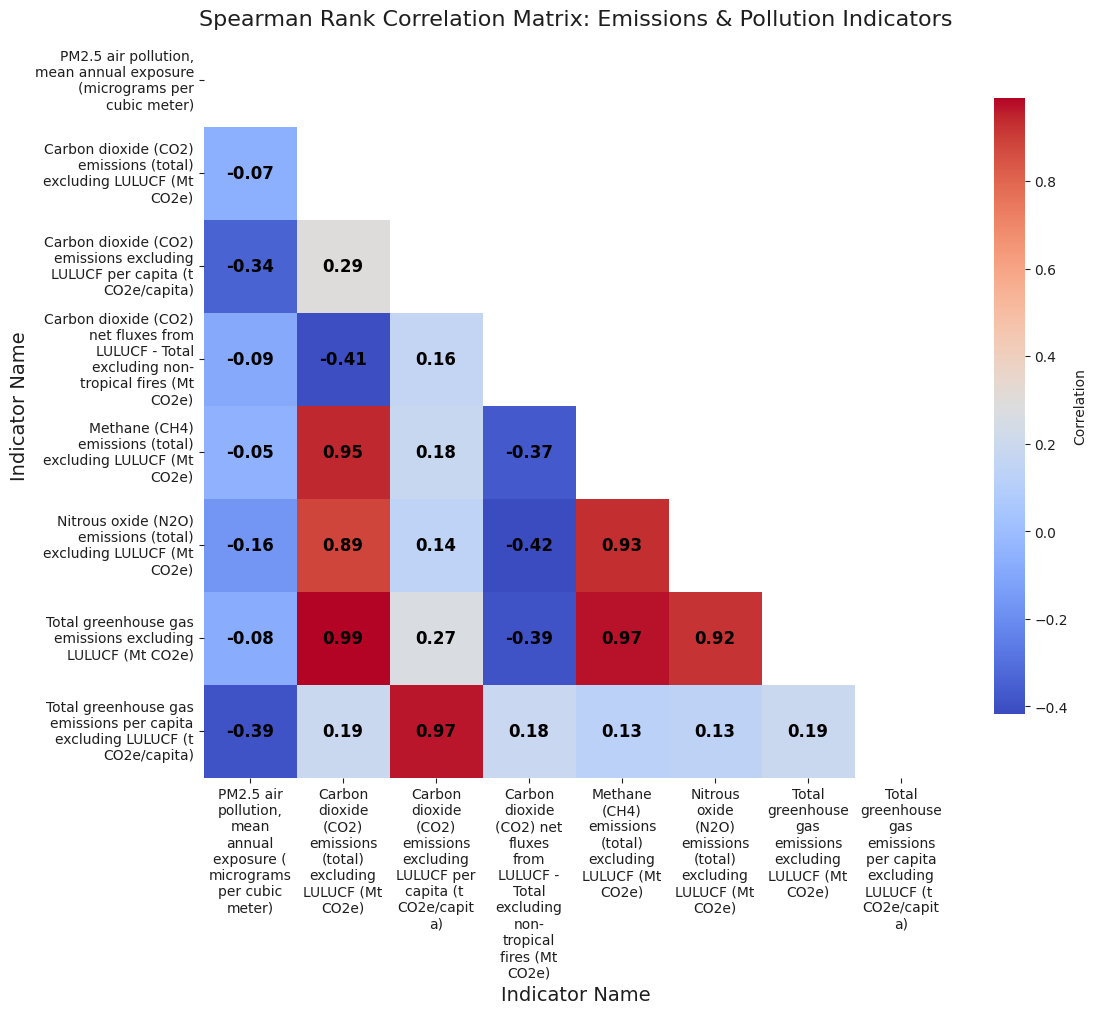

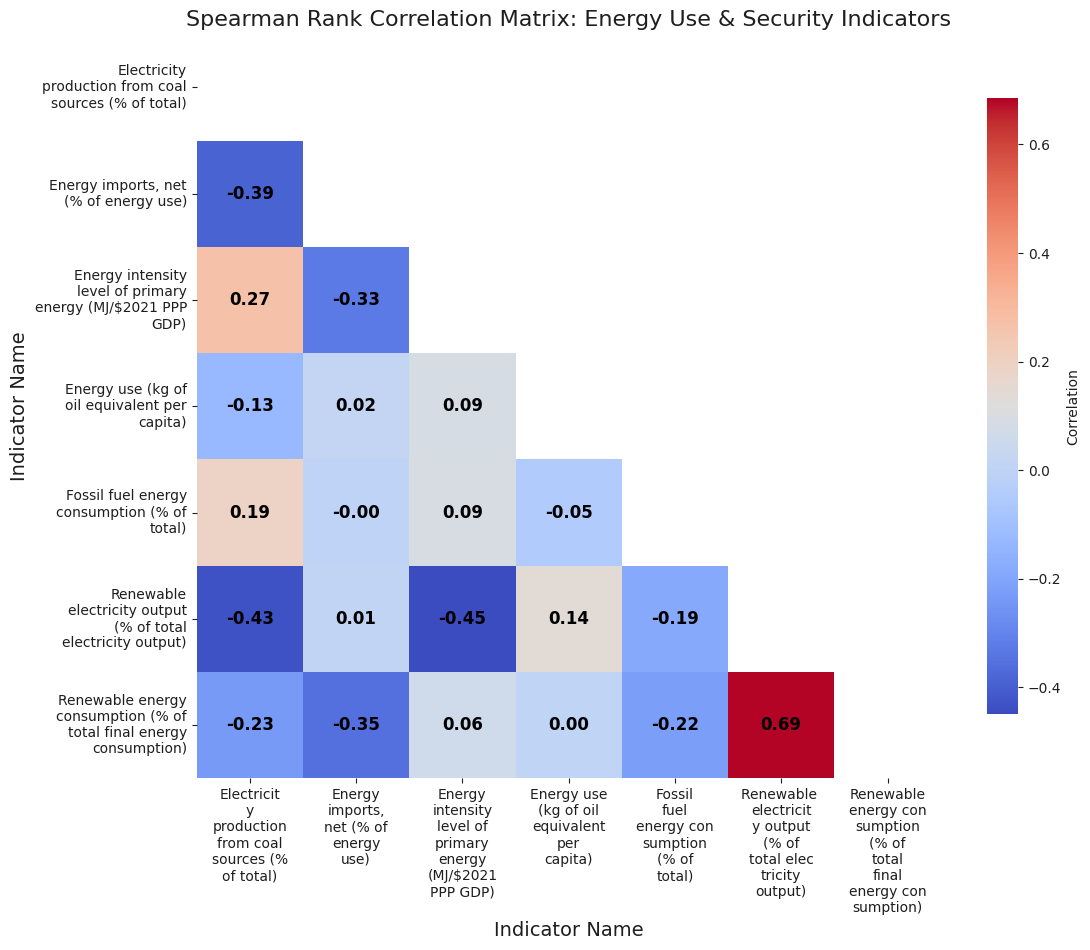

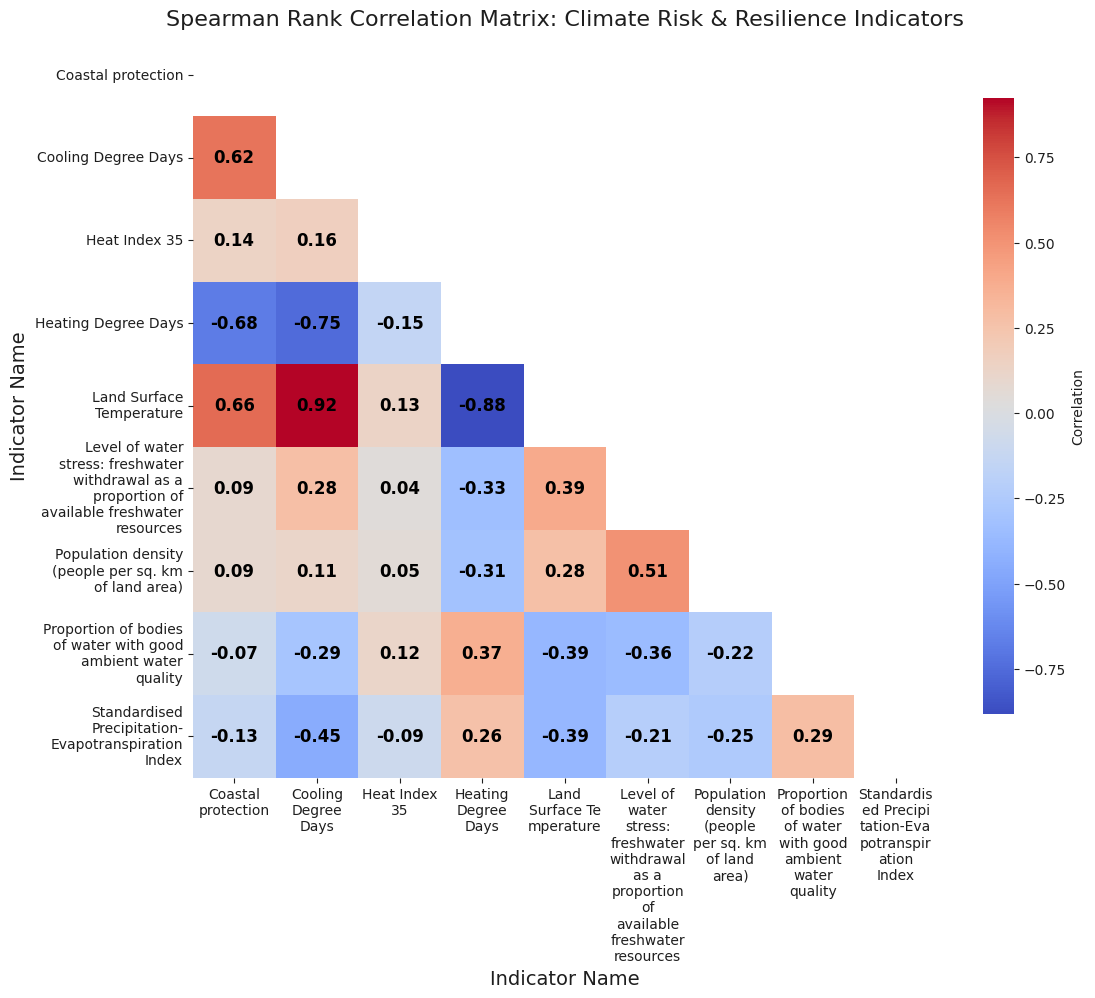

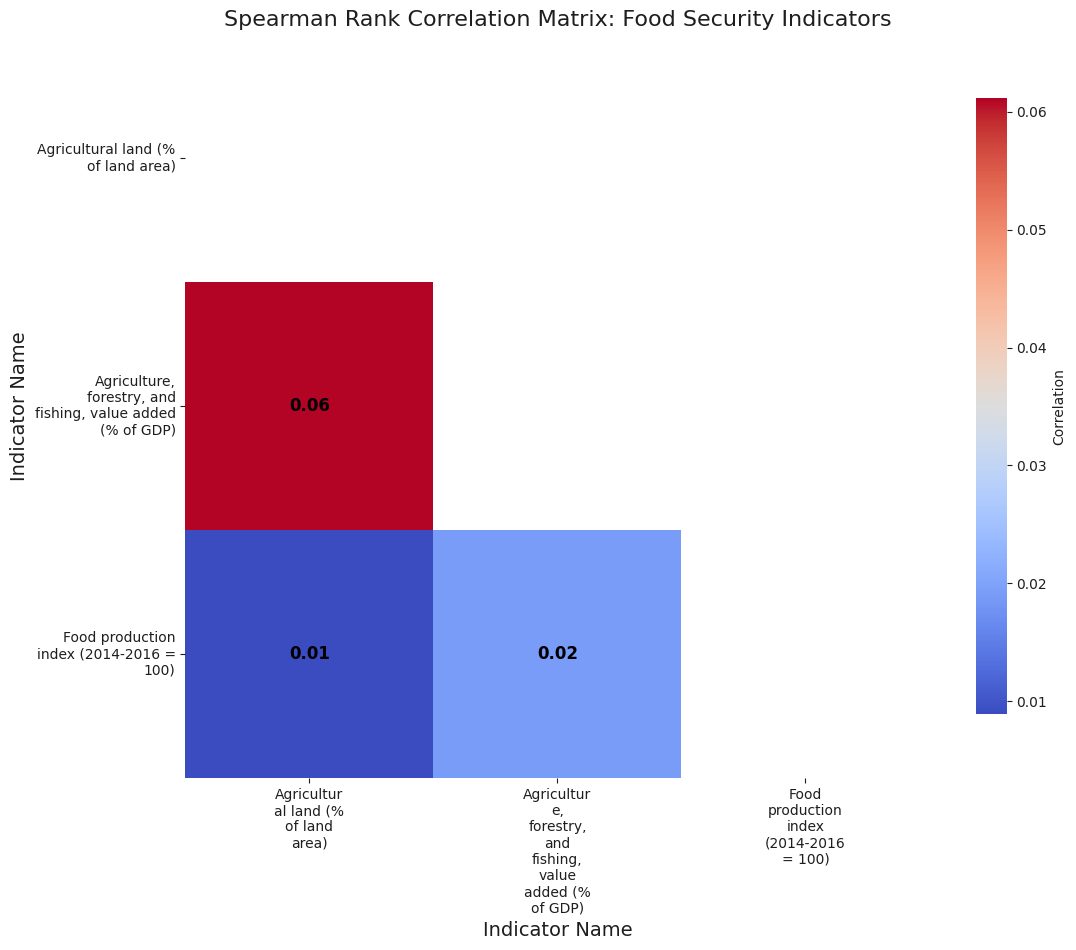

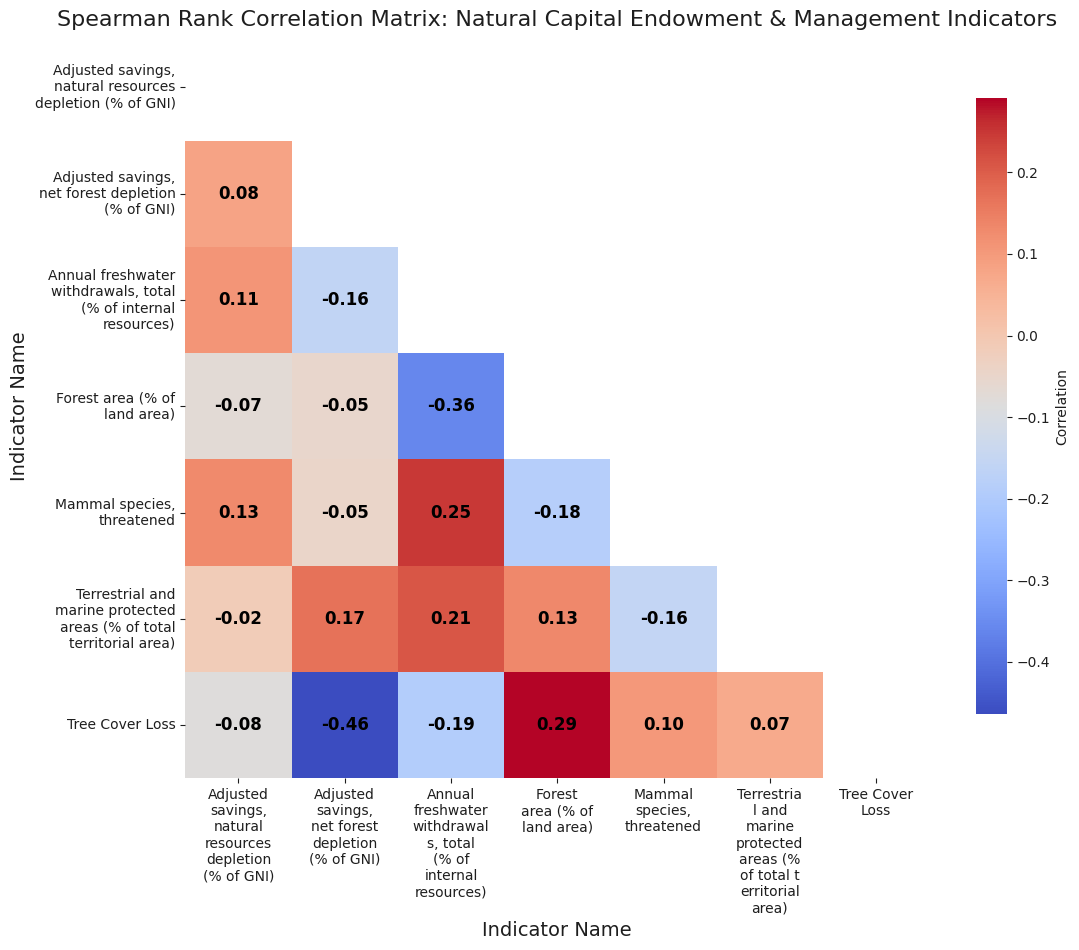

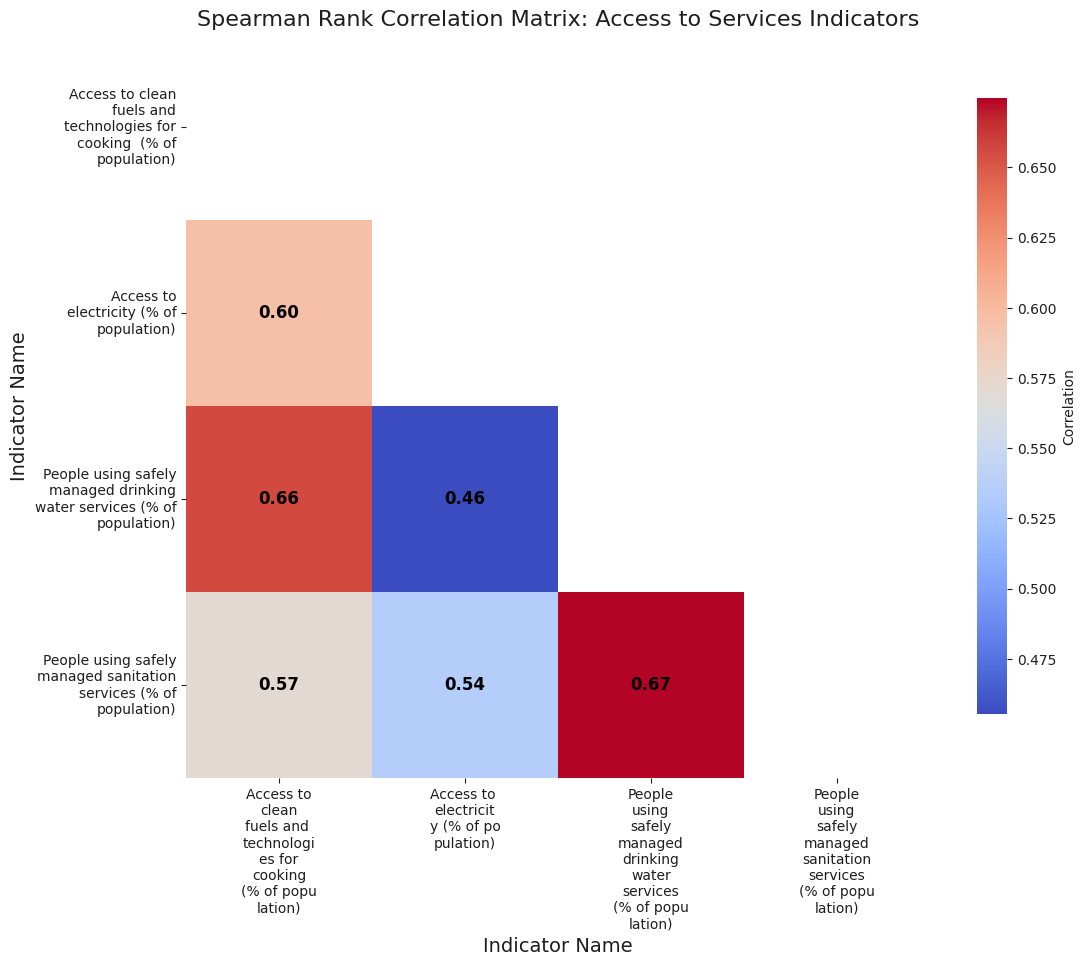

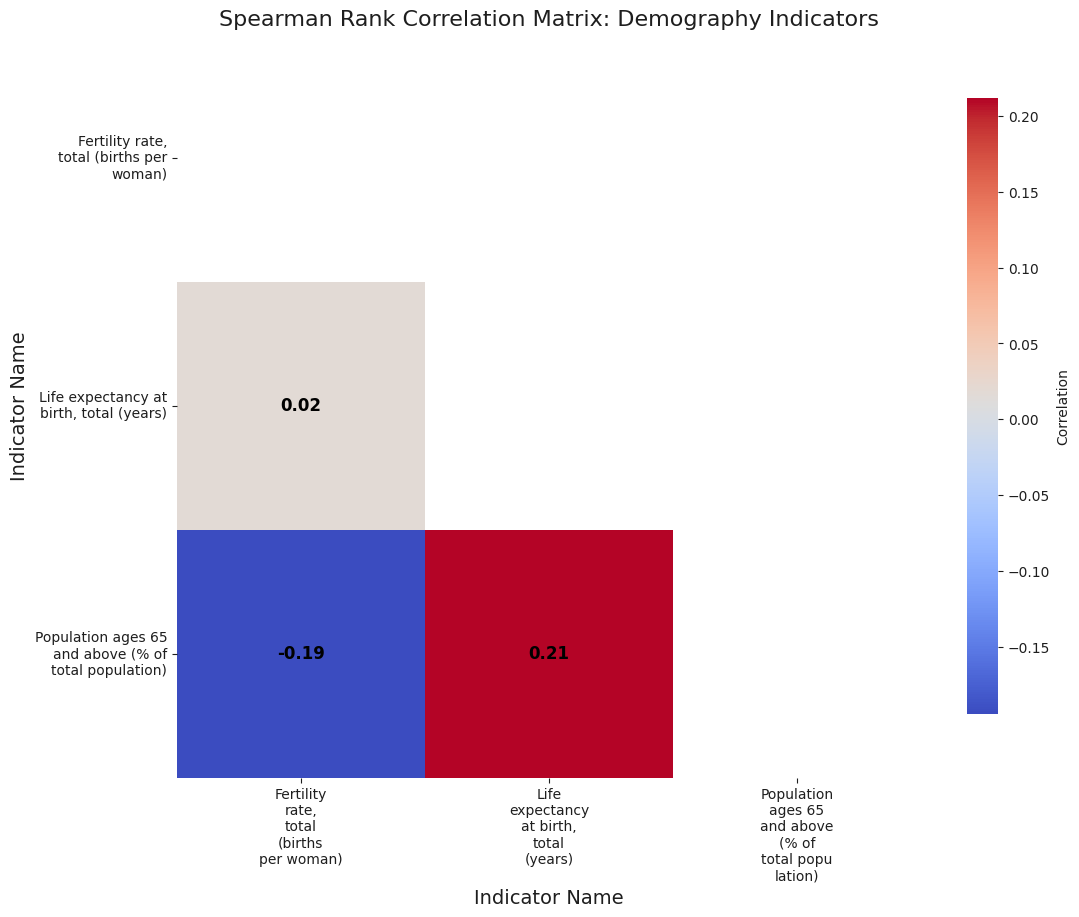

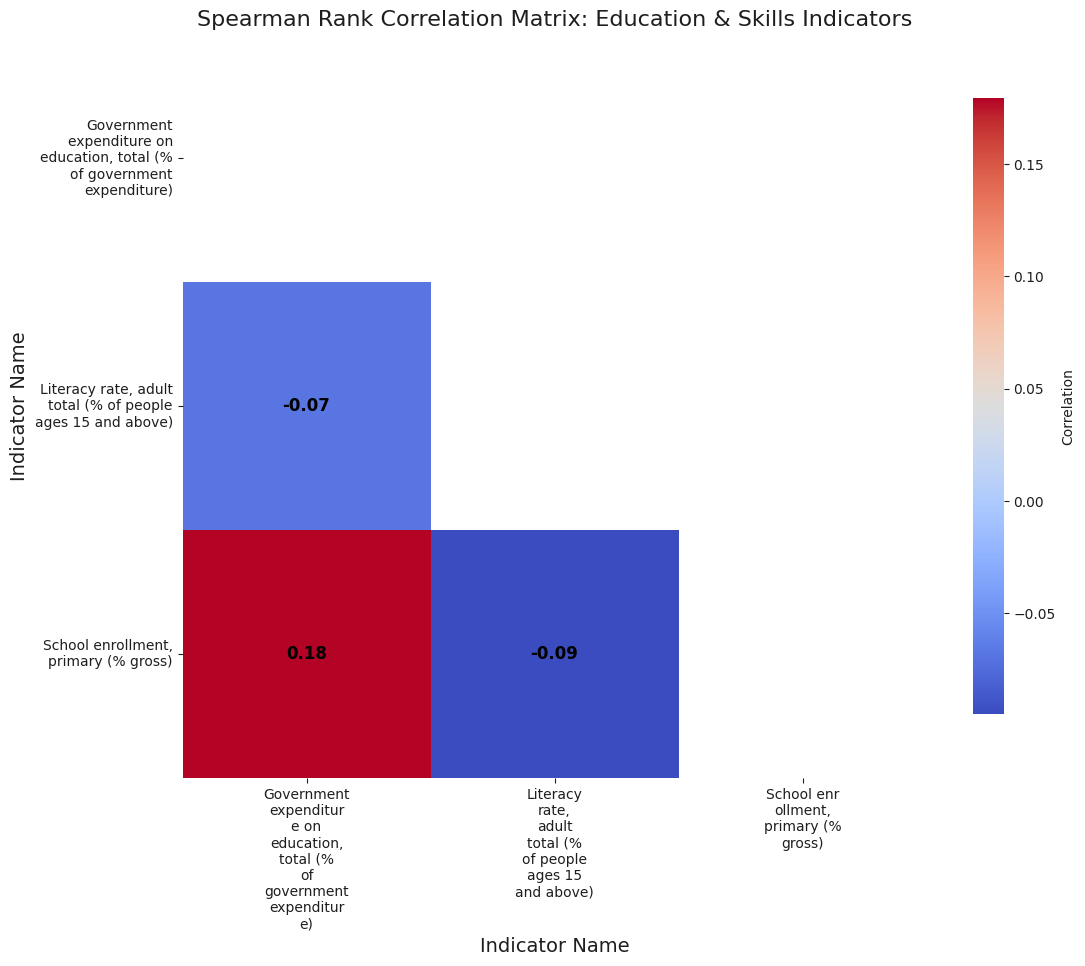

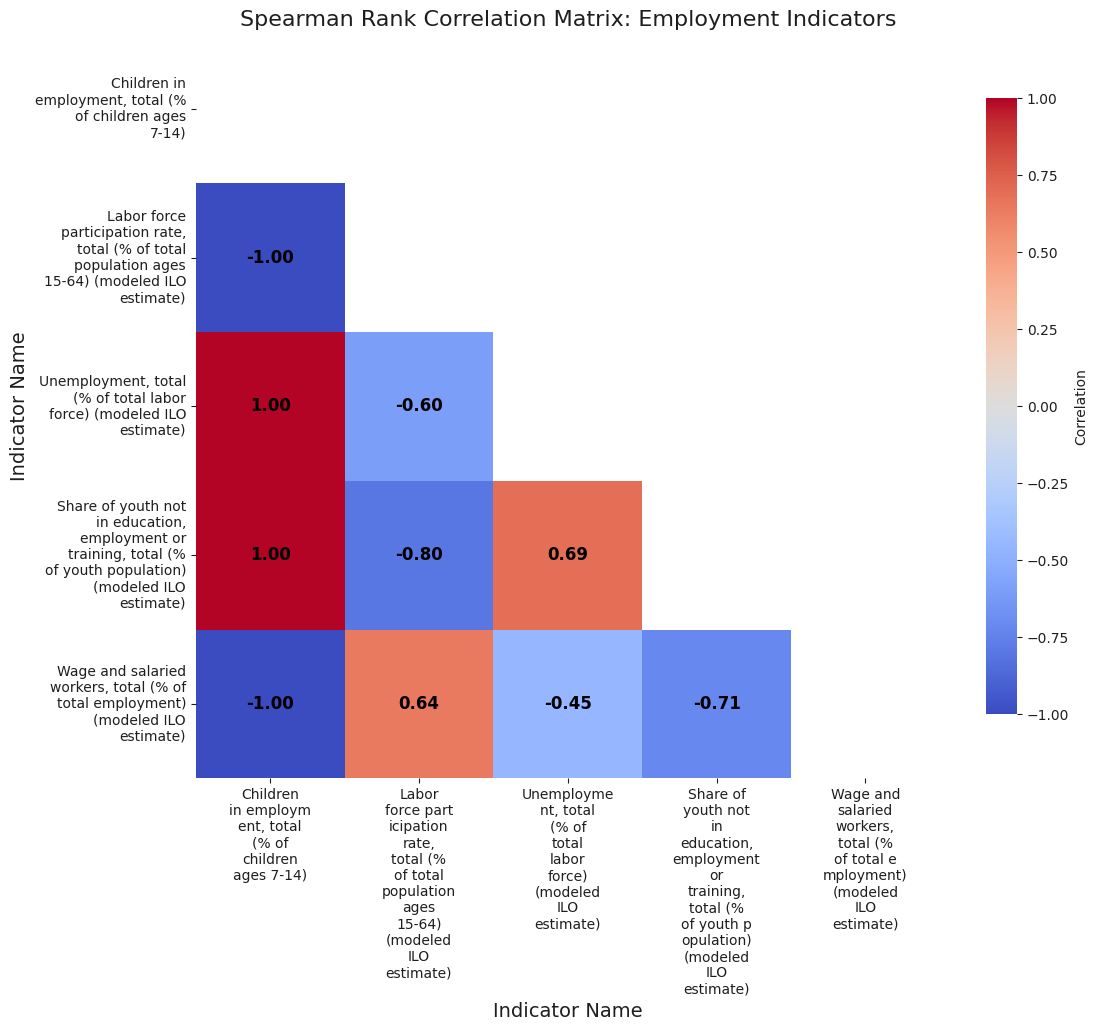

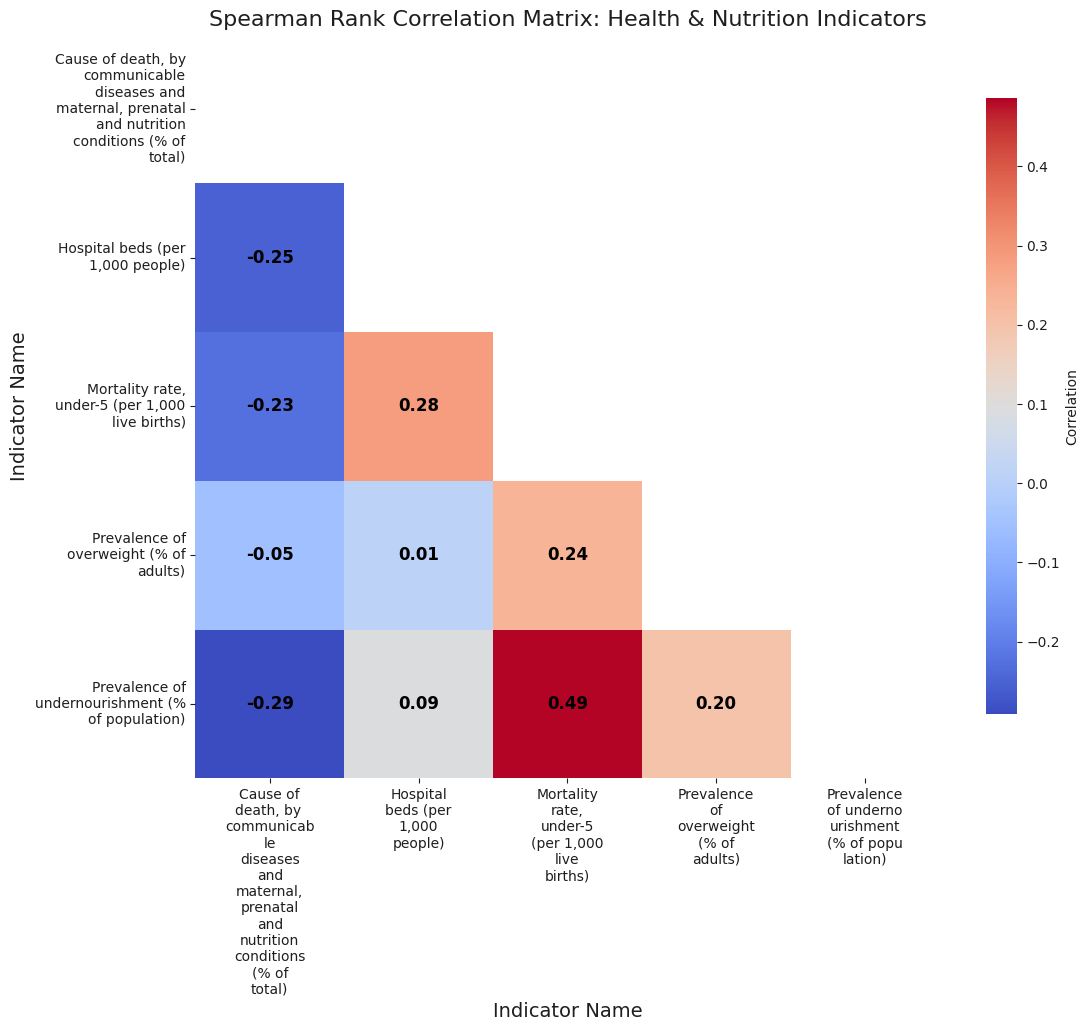

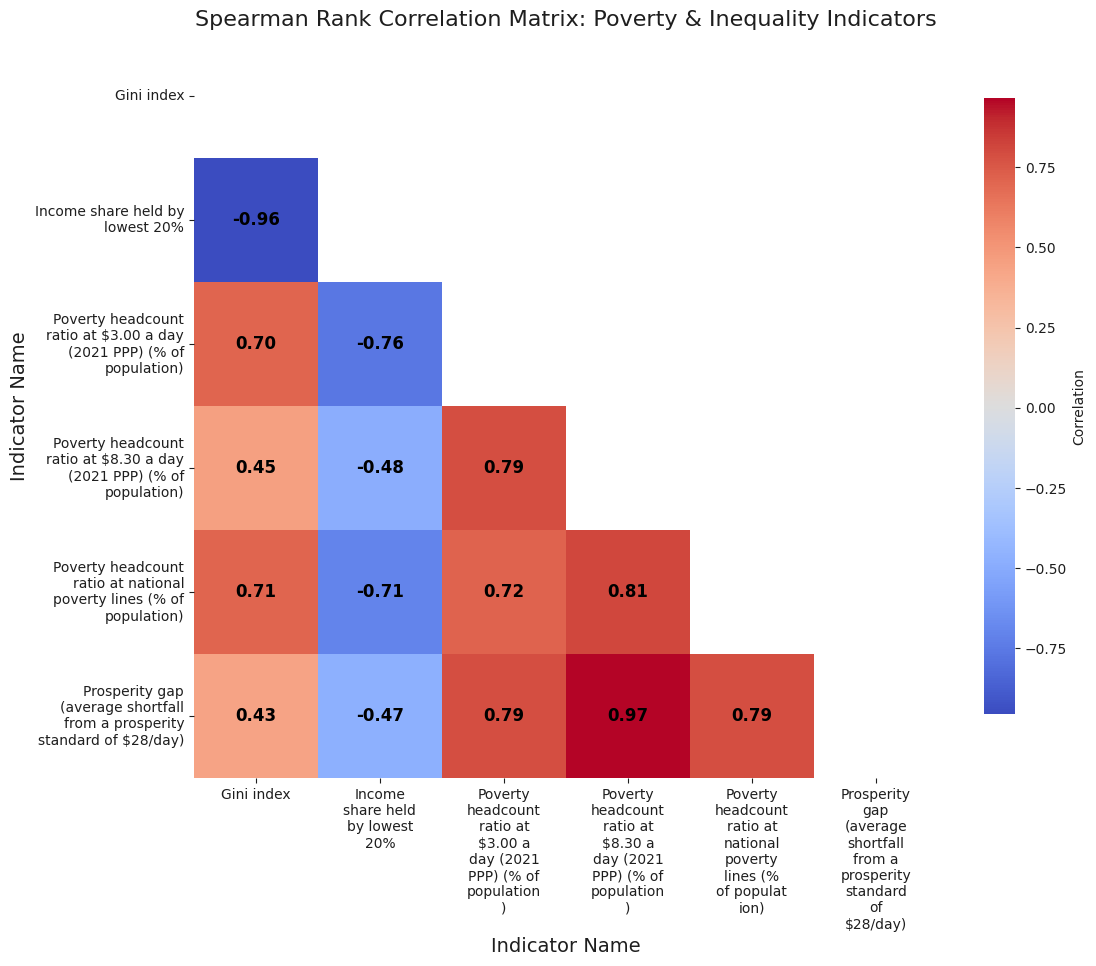

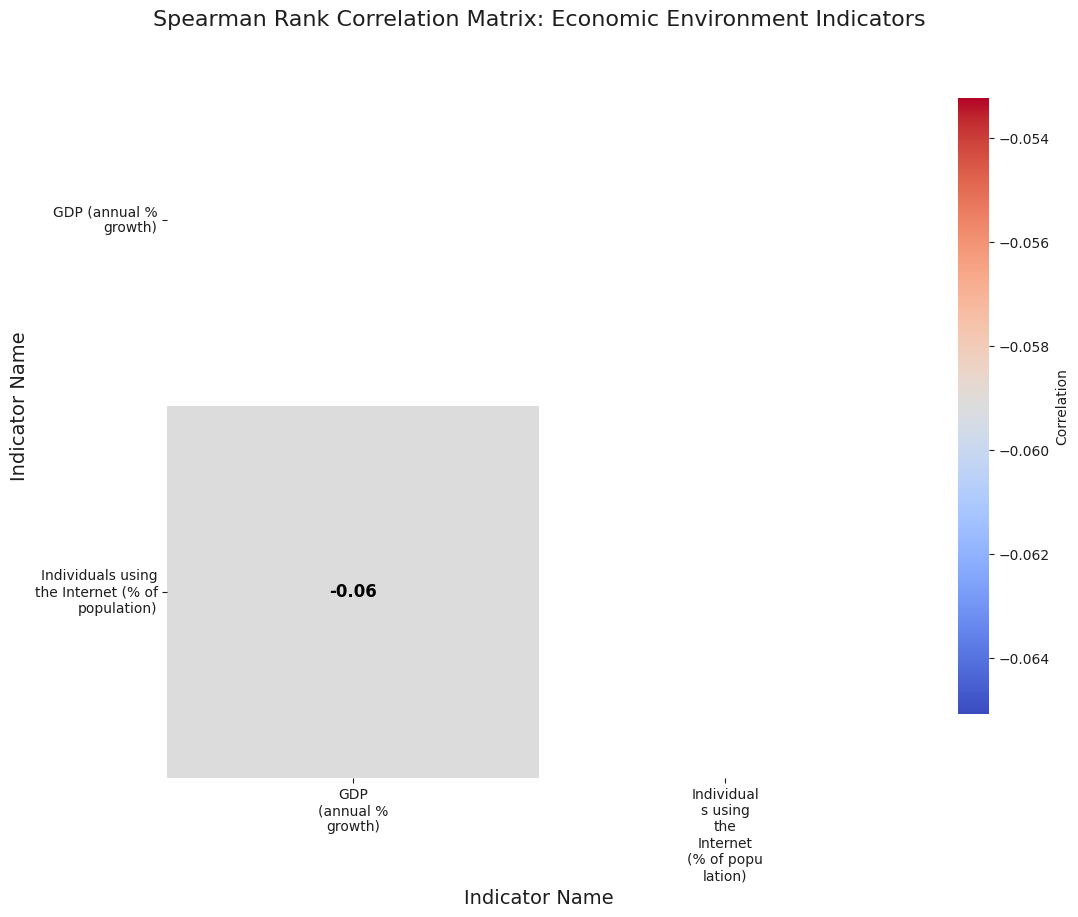

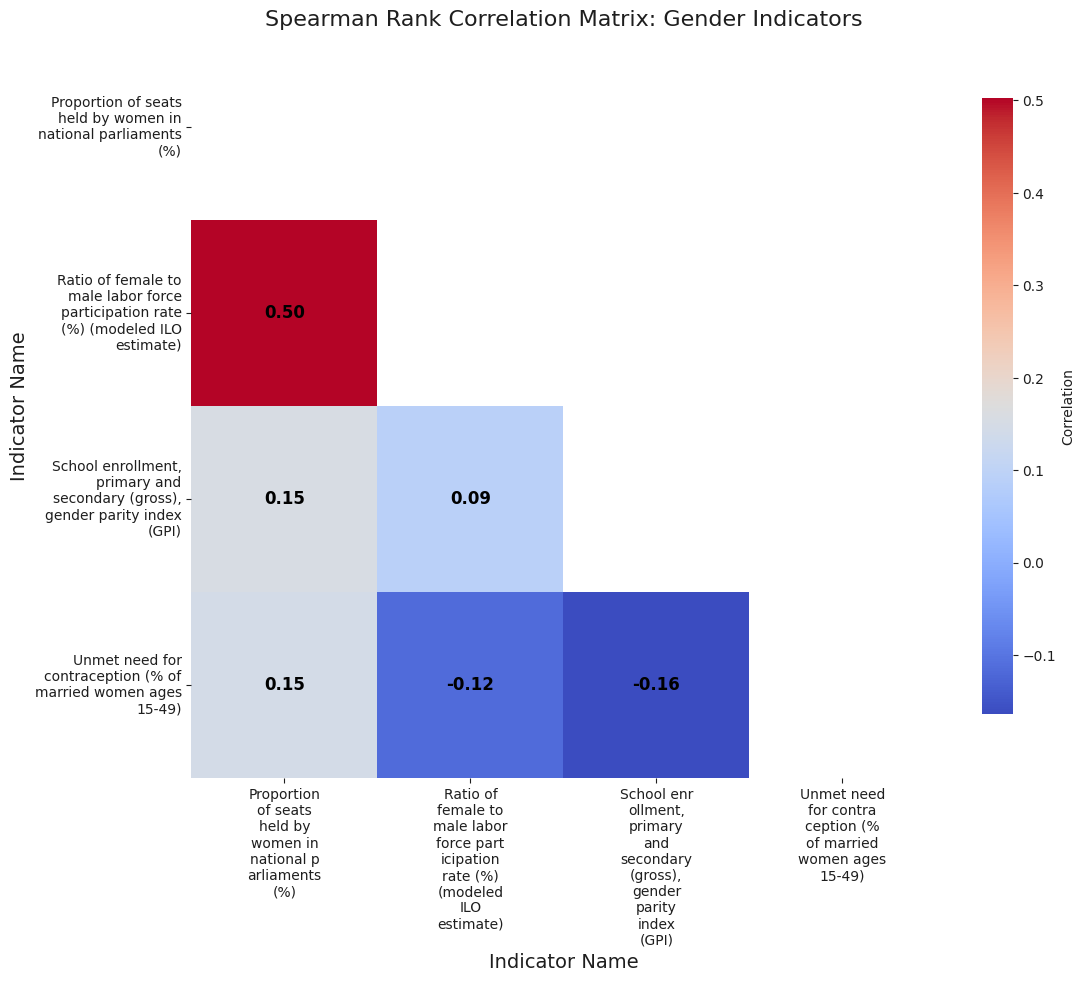

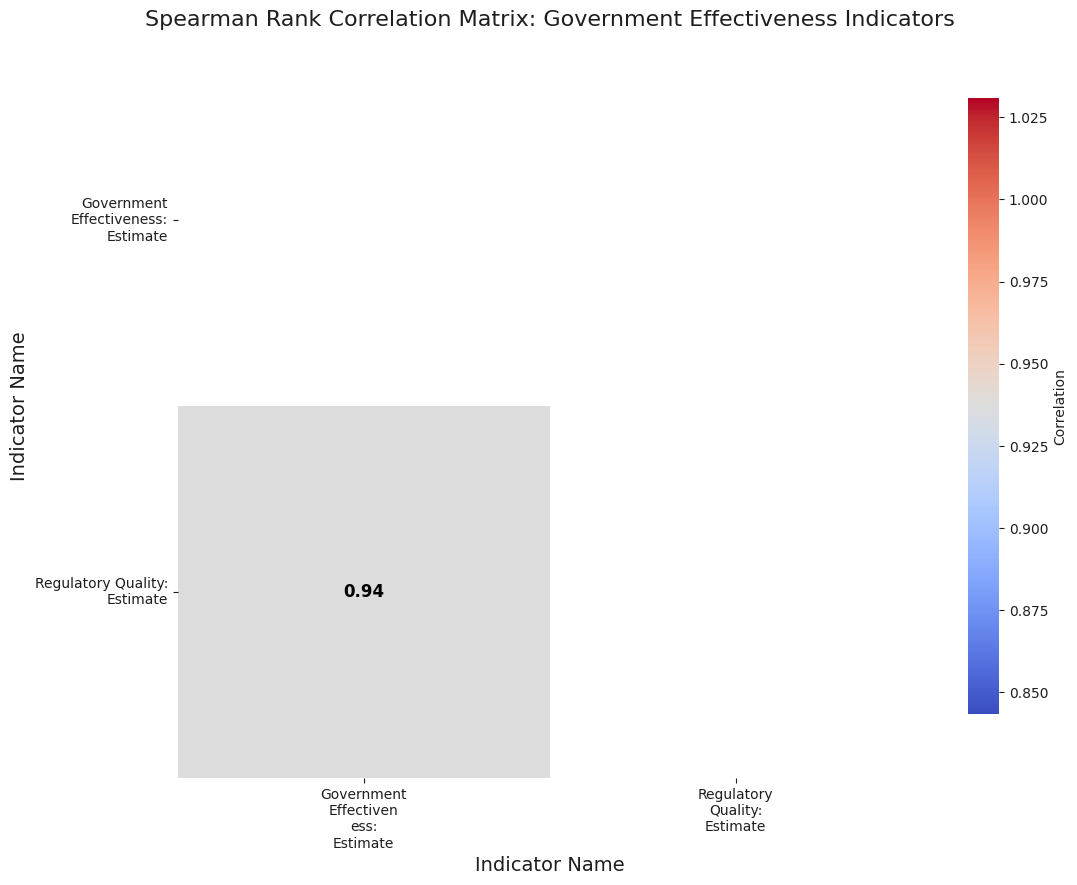

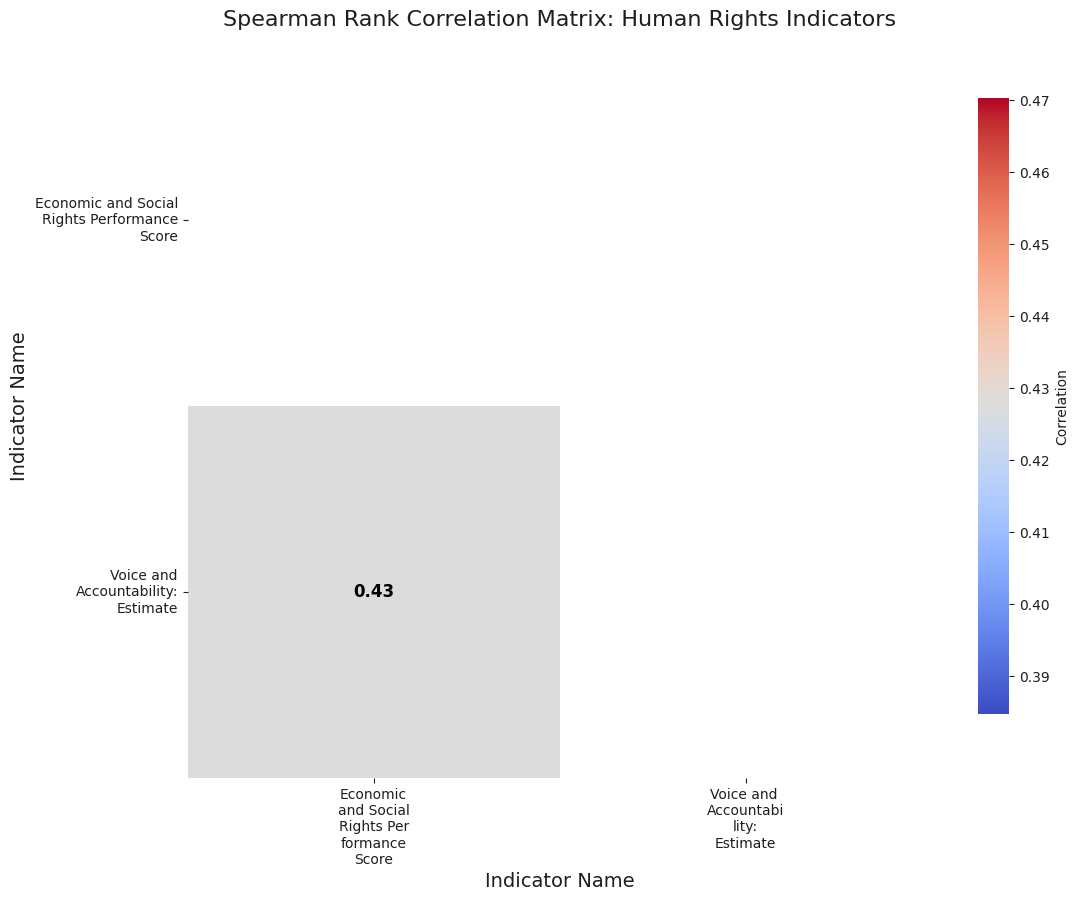

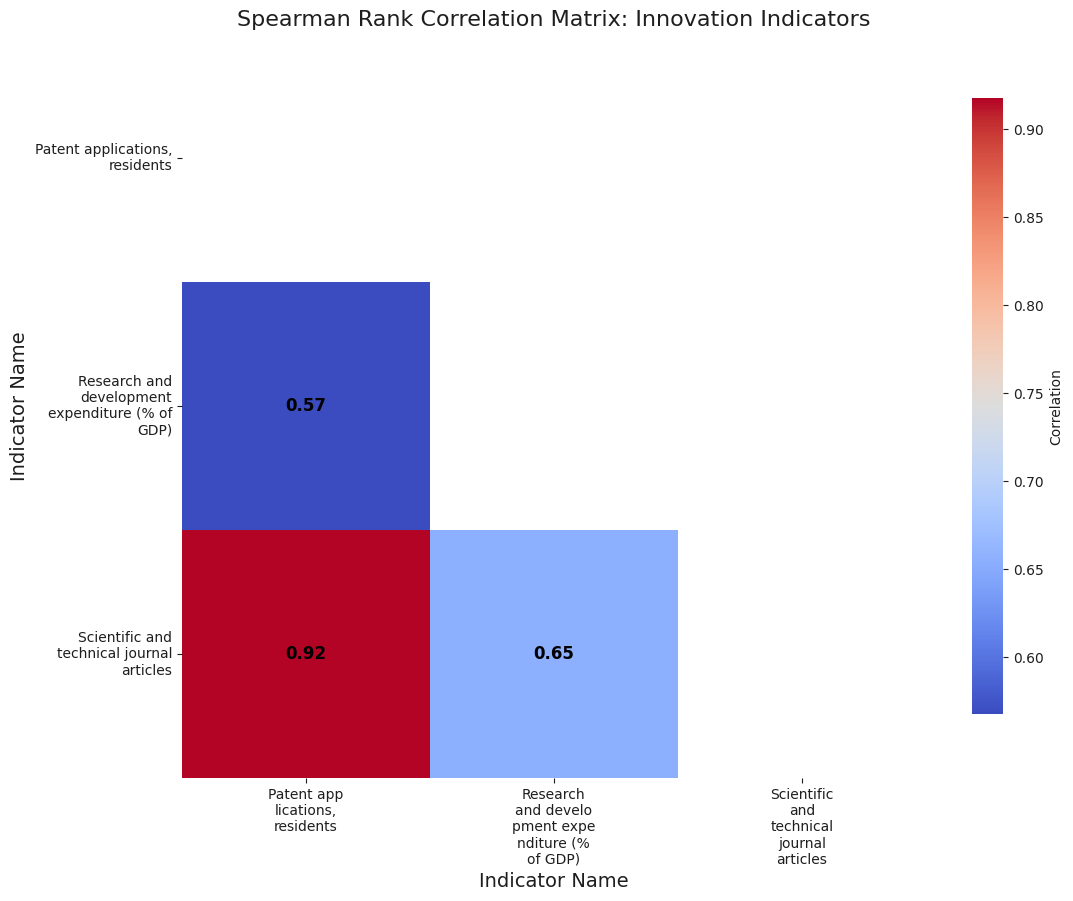

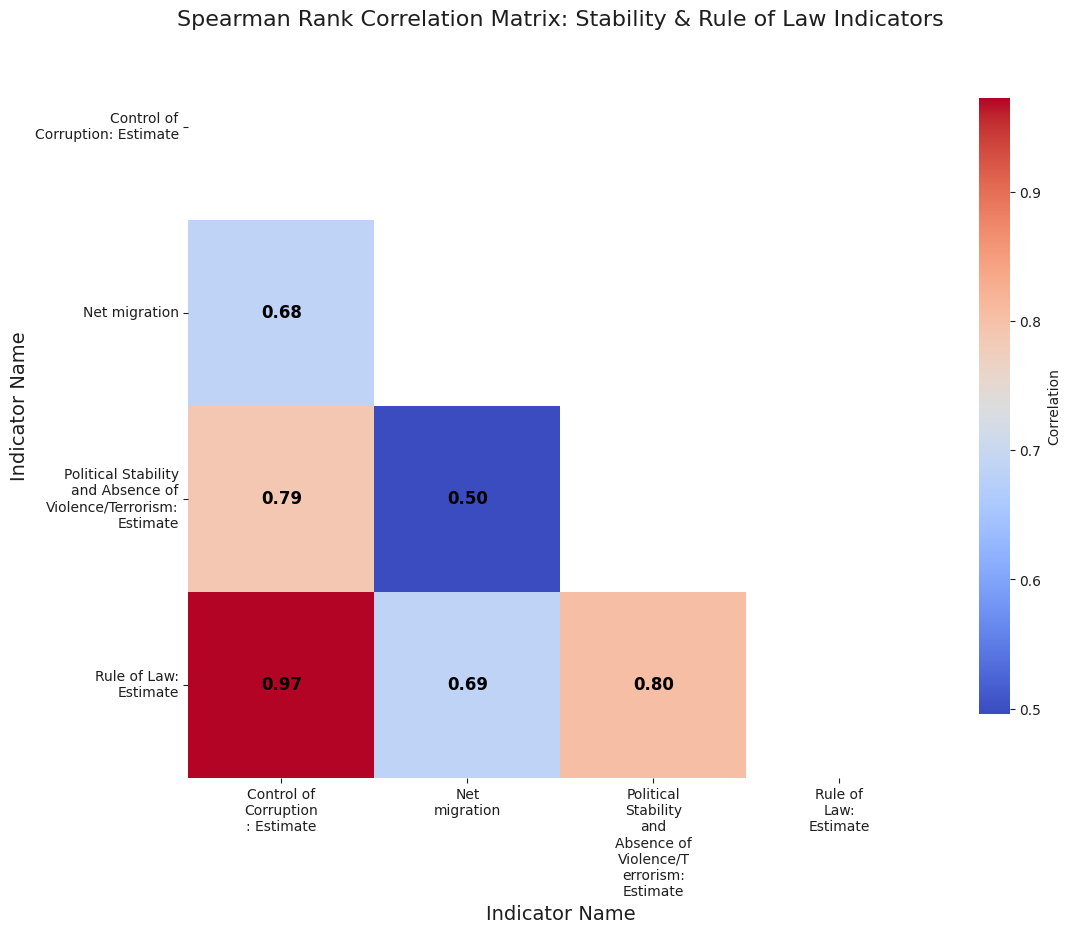

In [94]:
criteria = {
    "Emissions & Pollution": emissions_polution_europe,
    "Energy Use & Security": energy_security_europe,
    "Climate Risk & Resilience": climate_resilience_europe,
    "Food Security": food_security_europe,
    "Natural Capital Endowment & Management": endowment_management_europe,
    "Access to Services": access_services_europe,
    "Demography": demography_europe,
    "Education & Skills": education_skills_europe,
    "Employment": employment_europe,
    "Health & Nutrition": health_nutrition_europe,
    "Poverty & Inequality": poverty_inequality_europe,
    "Economic Environment": economic_environment_europe,
    "Gender": gender_europe,
    "Government Effectiveness": gov_effectiveness_europe,
    "Human Rights": human_rights_europe,
    "Innovation": innovation_europe,
    "Stability & Rule of Law": stability_rule_law_europe
}

correlation_heatmap(criteria)

### Highly Correlated Variables

- Total Greenhouse, CO2, CH4 and N2O emissions (all pairs go from 0.92-0.99); Total Greenhouse and CO2 per capita (0.97)       
- Land Surface Temperature and Cooling Degree Days (0.92); Land Surface Temperature and Heating Degree Days (-0.88)           
- Children in employment with all the other variables (1.00);                                                                            
- Prosperity Gap and Poverty Headcount Ratio at 8.30 (0.97); Income share held by the lowest 20% and Gini index  (-0.96)      
- Regulatory Quality and Government Effectiveness (0.94)                                                                      
- Scientific Journals and Patent Applications  (0.92)                                                                         
- Rule of Law and Control of Corruption (0.97)                                                                                 


# <span style="color:#e0bda8">10. Missing Value Imputation Test  </span>

### <span style="color:#e0bda8">10.0.  Variable Removal and Auxiliary Functions </span>

We end this stage with 22 Environmental, 19 Social and 11 Governance variables (total 52)

In [95]:
iso_code = ['ISO3 code']

env_missing = ['Mammal species, threatened', 
               'Proportion of bodies of water with good ambient water quality',
               'Coastal protection']

env_ambiguous = ['Agricultural land (% of land area)',
                 'Population density (people per sq. km of land area)']

env_redundant = ['Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)', 
                 'Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)', 
                 'Total greenhouse gas emissions excluding LULUCF (Mt CO2e)', 
                 'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)', 
                 'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
                 'Land Surface Temperature']

env_low_var = ['Heat Index 35']

soc_missing = ['Children in employment, total (% of children ages 7-14)',  
               'Literacy rate, adult total (% of people ages 15 and above)', 
               'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)']

soc_ambiguous = ['Population ages 65 and above (% of total population)']

soc_redundant = ['Income share held by lowest 20%',
                 'Prosperity gap (average shortfall from a prosperity standard of $28/day)']

soc_low_var = ['Access to electricity (% of population)']

gov_missing = ['Unmet need for contraception (% of married women ages 15-49)']

gov_ambiguous = ['GDP (annual % growth)']

gov_redundant = ['Regulatory Quality: Estimate', 
                 'Control of Corruption: Estimate',
                 'Scientific and technical journal articles']

gov_low_var = ['School enrollment, primary and secondary (gross), gender parity index (GPI)']



In [96]:
vars_removed = iso_code + env_missing + env_ambiguous  + env_redundant + env_low_var + soc_missing + soc_ambiguous + soc_redundant + soc_low_var + gov_missing + gov_ambiguous + gov_redundant + gov_low_var 
vars_to_drop = [c for c in vars_removed if c in df_europe.columns]

df_clean = df_europe.drop(columns=vars_to_drop)

In [97]:
df_env_raw = df_europe[[e for e in env_indicators if e in df_europe.columns]]
df_soc_raw = df_europe[[s for s in soc_indicators if s in df_europe.columns]]
df_gov_raw = df_europe[[g for g in gov_indicators if g in df_europe.columns]]

df_env_raw.to_csv(os.path.join(DATA_RAW, "df_env_raw.csv"))
df_soc_raw.to_csv(os.path.join(DATA_RAW, "df_soc_raw.csv"))
df_gov_raw.to_csv(os.path.join(DATA_RAW, "df_gov_raw.csv"))


In [98]:
df_env_raw.loc['Latvia']

Indicator name,"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e),Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e),Total greenhouse gas emissions excluding LULUCF (Mt CO2e),Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita),Electricity production from coal sources (% of total),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),Renewable electricity output (% of total electricity output),Renewable energy consumption (% of total final energy consumption),Coastal protection,Cooling Degree Days,Heat Index 35,Heating Degree Days,Land Surface Temperature,Level of water stress: freshwater withdrawal as a proportion of available freshwater resources,Population density (people per sq. km of land area),Proportion of bodies of water with good ambient water quality,Standardised Precipitation-Evapotranspiration Index,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Food production index (2014-2016 = 100),"Adjusted savings, natural resources depletion (% of GNI)","Adjusted savings, net forest depletion (% of GNI)","Annual freshwater withdrawals, total (% of internal resources)",Forest area (% of land area),"Mammal species, threatened",Terrestrial and marine protected areas (% of total territorial area),Tree Cover Loss
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012,14.9825,8.0274,3.9460,-4.8945,2.2319,1.9419,12.5754,6.1816,0.0324,60.9111,3.79,2171.0787,58.0287,66.6327,40.4,62.29,90.48,0.0,8177.31,7.9684,1.4626,32.6919,NaN,1.5391,29.5852,3.5329,87.12,0.1081,0.0,1.4652,54.3148,NaN,NaN,34285.4159
2013,15.4094,7.7794,3.8653,-3.6158,2.2281,1.9338,12.3292,6.1259,0.0483,60.4801,3.65,2156.5883,58.9126,56.9196,39.6,62.29,139.71,0.0,7638.60,9.0461,1.3907,32.3436,NaN,-0.5302,30.1638,3.2121,84.64,0.0706,0.0,1.3932,54.3769,NaN,17.8,27766.4390
2014,16.0993,7.5739,3.7988,0.3455,2.2861,1.9489,12.2099,6.1240,0.0000,43.7074,3.58,2177.0297,56.7126,54.5330,40.2,62.29,222.33,0.0,7473.07,10.3591,0.9929,32.0405,NaN,-0.4437,30.0834,3.6164,88.76,0.0702,0.0,0.9947,54.4390,NaN,17.8,32203.1645
2015,13.6554,7.6480,3.8675,-0.9422,2.2854,2.1334,12.4808,6.3113,0.0000,55.5330,3.39,2155.8522,58.9693,50.1851,38.1,62.29,80.25,0.0,7026.59,10.5933,1.0412,31.7792,NaN,-1.3928,30.2843,3.5545,107.21,0.0274,0.0,1.0431,54.5011,NaN,17.8,30829.6865
2016,12.6031,7.4806,3.8175,-2.8055,2.2641,2.2863,12.4655,6.3615,0.0000,52.0818,3.30,2172.4388,0.0000,54.1842,38.5,62.29,122.33,0.0,7577.52,9.9053,1.0952,31.4901,NaN,0.6077,31.0315,3.3253,104.03,0.0149,0.0,1.0972,54.5633,NaN,17.5,44945.4171
2017,11.6680,7.4321,3.8265,-4.2994,2.2557,2.2161,12.3325,6.3496,0.0000,48.1887,3.31,2265.2169,0.0000,72.5229,42.6,62.29,33.61,0.0,7600.81,9.2809,1.0673,31.2123,74.97,1.7845,31.0637,3.6248,106.11,0.0285,0.0,1.0692,54.6255,NaN,17.5,47085.3062
2018,14.2076,8.1079,4.2071,-1.8910,2.2033,2.1760,12.9111,6.6995,0.1041,46.2654,3.35,2403.4998,0.0000,52.0315,41.0,62.29,247.49,0.0,7303.24,11.9063,1.0804,30.9701,NaN,-1.8415,31.1440,3.6610,83.61,0.0635,0.0,1.0823,54.6877,1.0,17.5,46923.5214
2019,12.4866,7.9078,4.1319,-3.6043,2.1884,2.2658,12.7841,6.6799,0.0000,48.4186,3.16,2343.5158,0.0000,49.5823,41.5,62.29,146.48,0.0,6878.36,11.5942,1.0526,30.7555,NaN,-0.6596,31.4976,3.8534,104.75,0.0469,0.0,1.0545,54.7499,NaN,17.5,57402.9306
2020,11.6020,7.2771,3.8291,-0.8784,2.1616,2.3351,12.1885,6.4135,0.0009,48.6028,3.08,2251.3825,0.0000,63.7584,43.8,62.29,123.92,0.0,6499.20,10.9695,1.0678,30.5391,77.48,-0.7413,31.6407,4.0792,110.74,0.0242,0.0,1.0697,54.8094,NaN,17.5,50462.7838


In [99]:
df_env_filtered = df_clean[[e for e in env_indicators if e in df_clean.columns]]
df_soc_filtered = df_clean[[s for s in soc_indicators if s in df_clean.columns]]
df_gov_filtered = df_clean[[g for g in gov_indicators if g in df_clean.columns]]

df_env_filtered.to_csv(os.path.join(DATA_PROCESSED, "df_env_filtered.csv"))
df_soc_filtered.to_csv(os.path.join(DATA_PROCESSED, "df_soc_filtered.csv"))
df_gov_filtered.to_csv(os.path.join(DATA_PROCESSED, "df_gov_filtered.csv"))

In [100]:
def imputation_evaluation(df_init, missing_fraction=0.1):
    """
    Evaluates multiple imputation methods by introducing artificial missing values
    and comparing reconstructed values against the true data.

    Parameters:
        df_init (DataFrame): Original dataset.
        missing_fraction (float): Fraction of values to randomly remove per column.

    Returns:
        DataFrame: Error metrics (MAE% and RMSE%) for each method and feature.
    """

    np.random.seed(42)
    df = df_init.copy()

    # Reset index to ensure 'Year' and identifiers are accessible
    df = df.reset_index(drop=False)

    # Ensure 'Year' is datetime (required for time interpolation)
    df['Year'] = pd.to_datetime(df['Year'], format='%Y')

    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=np.number).columns

    # --- CREATE ARTIFICIAL MISSING VALUES ---
    df_missing = df.copy()
    mask = pd.DataFrame(False, index=df.index, columns=numeric_cols)

    for col in numeric_cols:
        n_missing = max(1, int(len(df) * missing_fraction))

        # Only sample from non-missing values
        valid_indices = df.index[df[col].notna()]
        n_missing = min(n_missing, len(valid_indices) - 1)

        missing_indices = np.random.choice(valid_indices, size=n_missing, replace=False)

        df_missing.loc[missing_indices, col] = np.nan
        mask.loc[missing_indices, col] = True  # Track artificially removed values

    numeric_cols = df_missing.select_dtypes(include=np.number).columns

    # --- IMPUTATION METHODS ---

    # 1. Median imputation (baseline)
    df_median = df_missing.copy()
    for col in numeric_cols:
        df_median[col] = df_median[col].fillna(df_median[col].median())

    # 2. Time-based interpolation (within each country)
    df_interpolated = df_missing.copy()

    def interpolate_time(group):
        original_index = group.index
        group = group.set_index('Year')

        group[numeric_cols] = group[numeric_cols].interpolate(method='time')
        group[numeric_cols] = group[numeric_cols].ffill().bfill()

        group = group.reset_index()
        group.index = original_index
        return group

    df_interpolated = df_interpolated.groupby('Economy', group_keys=False).apply(
        interpolate_time, include_groups=False
    )

    # 3–6. KNN-based imputations with different scaling strategies
    knn = KNNImputer(n_neighbors=5)

    # Robust scaling
    df_knn_robust = df_missing.copy()
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df_knn_robust[numeric_cols])
    df_knn_robust[numeric_cols] = scaler.inverse_transform(knn.fit_transform(X_scaled))

    # MinMax scaling
    df_knn_minmax = df_missing.copy()
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_knn_minmax[numeric_cols])
    df_knn_minmax[numeric_cols] = scaler.inverse_transform(knn.fit_transform(X_scaled))

    # Standard scaling
    df_knn_standard = df_missing.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_knn_standard[numeric_cols])
    df_knn_standard[numeric_cols] = scaler.inverse_transform(knn.fit_transform(X_scaled))

    # No scaling
    df_knn_no_scale = df_missing.copy()
    df_knn_no_scale[numeric_cols] = knn.fit_transform(df_knn_no_scale[numeric_cols])

    # --- ERROR COMPUTATION ---
    def compute_errors(true_vals, pred_vals, col_range):
        """Compute MAE and RMSE (absolute and percentage)."""
        valid = true_vals.notna() & pred_vals.notna()
        if valid.sum() == 0:
            return np.nan, np.nan, np.nan, np.nan

        mae = mean_absolute_error(true_vals[valid], pred_vals[valid])
        rmse = np.sqrt(mean_squared_error(true_vals[valid], pred_vals[valid]))

        mae_pct = (mae / col_range) * 100
        rmse_pct = (rmse / col_range) * 100

        return mae, rmse, mae_pct, rmse_pct

    # Store results
    results_dict = {
        'MAE_Median_%': {}, 'MAE_Interpolation_%': {}, 'MAE_KNN_ROBUST_%': {},
        'MAE_KNN_MINMAX_%': {}, 'MAE_KNN_STANDARD_%': {}, 'MAE_KNN_NO_SCALE_%': {},
        'RMSE_Median_%': {}, 'RMSE_Interpolation_%': {}, 'RMSE_KNN_ROBUST_%': {},
        'RMSE_KNN_MINMAX_%': {}, 'RMSE_KNN_STANDARD_%': {}, 'RMSE_KNN_NO_SCALE_%': {}
    }

    for col in numeric_cols:
        mask_col = mask[col]
        true_vals = df.loc[mask_col, col]

        # Use range for scale-normalized error
        col_range = max(df[col].max() - df[col].min(), 1e-9)

        # Evaluate each method
        for method, df_method, mae_key, rmse_key in [
            ('Median', df_median, 'MAE_Median_%', 'RMSE_Median_%'),
            ('Interpolation', df_interpolated, 'MAE_Interpolation_%', 'RMSE_Interpolation_%'),
            ('KNN_ROBUST', df_knn_robust, 'MAE_KNN_ROBUST_%', 'RMSE_KNN_ROBUST_%'),
            ('KNN_MINMAX', df_knn_minmax, 'MAE_KNN_MINMAX_%', 'RMSE_KNN_MINMAX_%'),
            ('KNN_STANDARD', df_knn_standard, 'MAE_KNN_STANDARD_%', 'RMSE_KNN_STANDARD_%'),
            ('KNN_NO_SCALE', df_knn_no_scale, 'MAE_KNN_NO_SCALE_%', 'RMSE_KNN_NO_SCALE_%')
        ]:
            _, _, mae_pct, rmse_pct = compute_errors(
                true_vals,
                df_method.loc[mask_col, col],
                col_range
            )

            results_dict[mae_key][col] = mae_pct
            results_dict[rmse_key][col] = rmse_pct

    # Convert to DataFrame and sort by best-performing method
    results = pd.DataFrame(results_dict)
    results = results.sort_values('MAE_Interpolation_%')

    return results

In [101]:
def heatmap_evaluation(results, pillar_title=None, pillar_png=None):
    """
    Visualizes imputation error metrics using a heatmap.

    Parameters:
        results (DataFrame): Output from imputation_evaluation().
        pillar_title (str, optional): Title suffix.
        pillar_png (str, optional): Filename prefix for saving the plot.
    """

    plt.figure(figsize=(12, max(6, len(results) * 0.25)))

    sns.heatmap(
        results,
        cmap='RdYlGn_r',  
        annot=False,
        linewidths=0.3
    )

    plt.title(f'Imputation Method Error Comparison (%) — {pillar_title} Pillar')
    plt.xlabel('Imputation Method')
    plt.ylabel('Indicator')

    plt.tight_layout()

    if pillar_png:
        plt.savefig(
            os.path.join(EDA, f'{pillar_png}_imputation_heatmap.png'),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

## <span style="color:#e0bda8">10.1.  Environmental Pillar </span>

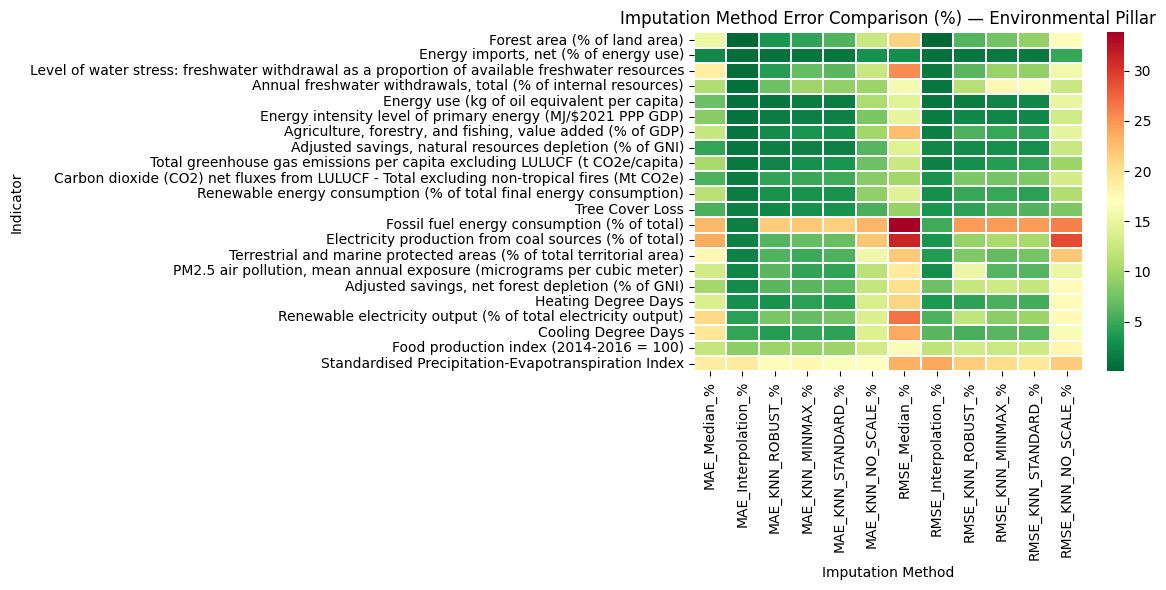

In [102]:
evaluation_env = imputation_evaluation(df_env_filtered, missing_fraction=0.1)
heatmap_evaluation(evaluation_env, pillar_title='Environmental', pillar_png='env')

## <span style="color:#e0bda8">10.2.  Social Pillar </span>

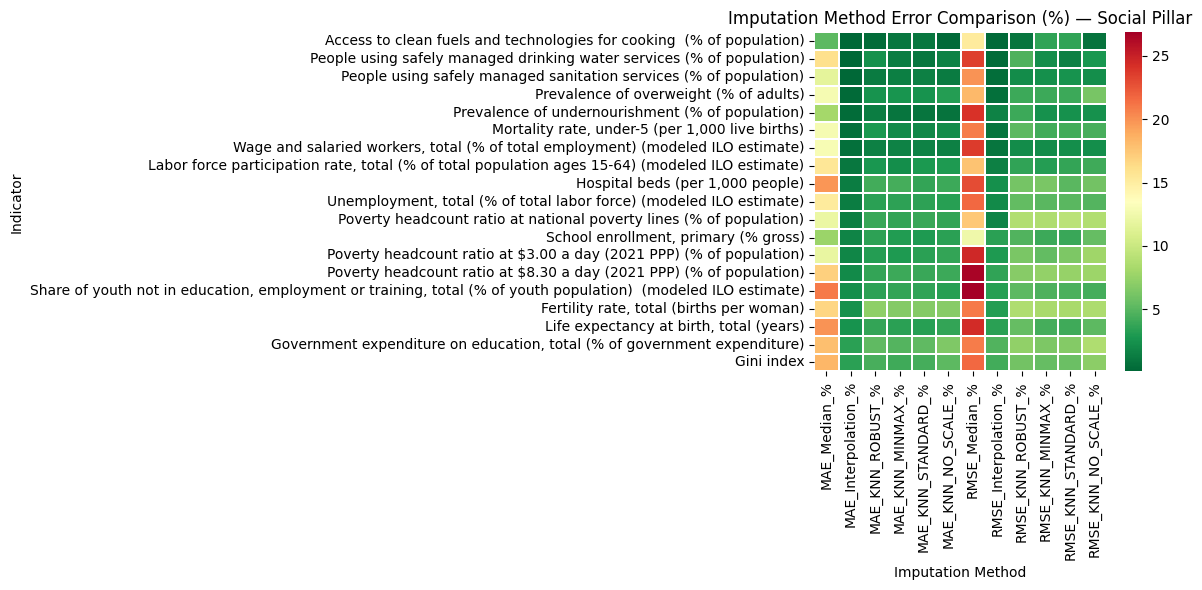

In [103]:
evaluation_soc = imputation_evaluation(df_soc_filtered, missing_fraction=0.1)
heatmap_evaluation(evaluation_soc, pillar_title='Social', pillar_png='soc')

## <span style="color:#e0bda8">10.3.  Governance Pillar </span>

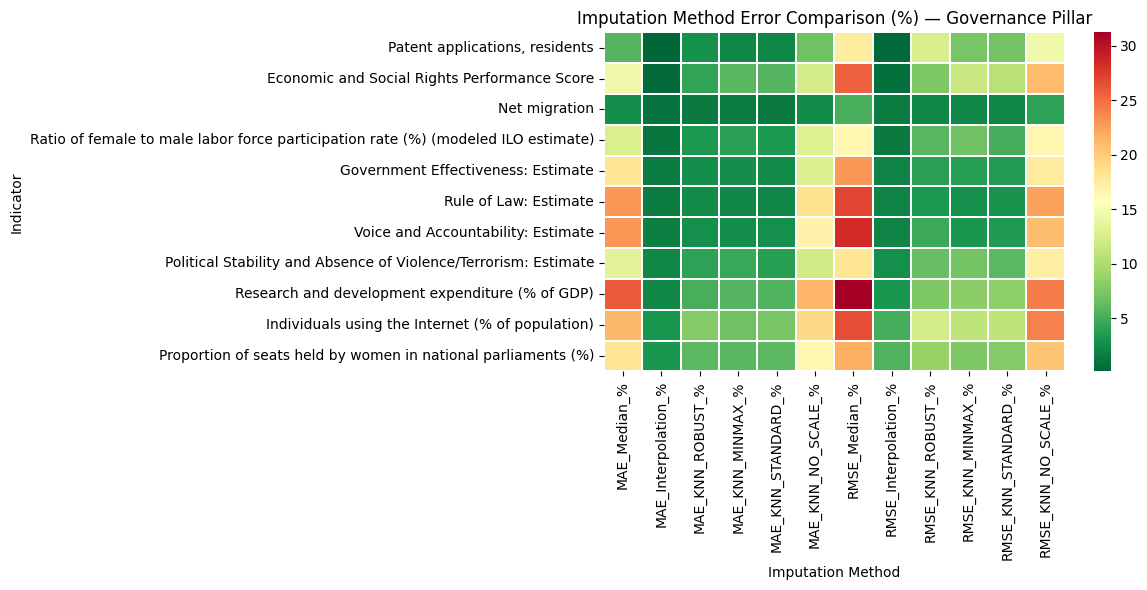

In [104]:
evaluation_gov = imputation_evaluation(df_gov_filtered, missing_fraction=0.1)
heatmap_evaluation(evaluation_gov, pillar_title='Governance', pillar_png='gov')